# DATA 2001 Group Assignment 2026

**Topic:** NSW regional statistics, Greater Sydney POI data, SA2 resource scoring, and report analysis.

**Due:** 20 May 2026, 11:59 PM

This notebook is structured to document the full workflow required for the group submission.

## Deliverables Checklist

- PDF report
- Jupyter Notebook describing the full workflow
- Tutor conversation in Week 12 or Week 13
- One group ZIP file submitted to Canvas

## Setup

In [45]:
from pathlib import Path
from tabulate import tabulate
import json
import math
import sqlite3
import urllib.parse
import urllib.request
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import geopandas as gpd
import requests

DATA_DIR = Path.cwd()
CSV_PATH = DATA_DIR / "Region summary_ New South Wales STE 1.csv"
DB_PATH = DATA_DIR / "data2001_assignment.sqlite"

CSV_PATH

WindowsPath('c:/Users/micro/OneDrive/Documents/DATA2001/DATA2001_assignment/Region summary_ New South Wales STE 1.csv')

# Task 1: NSW Summary Statistics

## 1.1 Load the NSW Region Summary CSV

In [46]:
df_raw = pd.read_csv(CSV_PATH)
df_raw.head()

,Measure Code,Parent Description,Description,2011,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,ERP_P_20,Estimated resident population - year ended 30 ...,Estimated resident population (no.),NaN,NaN,NaN,NaN,NaN,8046748.0,8110610.0,8097062.0,8166704.0,8341199.0,8479314.0,NaN
1,ERP_21,Estimated resident population - year ended 30 ...,Population density (persons/km2),NaN,NaN,NaN,NaN,NaN,10.0,10.1,10.1,10.2,10.4,10.6,NaN
2,ERP_M_20,Estimated resident population - year ended 30 ...,Estimated resident population - males (no.),NaN,NaN,NaN,NaN,NaN,3999452.0,4030710.0,4025393.0,4059763.0,4149032.0,4217861.0,NaN
3,ERP_F_20,Estimated resident population - year ended 30 ...,Estimated resident population - females (no.),NaN,NaN,NaN,NaN,NaN,4047296.0,4079900.0,4071669.0,4106941.0,4192167.0,4261453.0,NaN
4,ERP_19,Estimated resident population - year ended 30 ...,Median age - males (years),NaN,NaN,NaN,NaN,NaN,36.8,37.2,37.7,37.7,37.5,37.5,NaN


In [47]:
print("Shape:", df_raw.shape)
display(df_raw.info())
display(df_raw.describe(include="all"))

Shape: (800, 15)
<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Measure Code        800 non-null    str    
 1   Parent Description  800 non-null    str    
 2   Description         800 non-null    str    
 3   2011                259 non-null    float64
 4   2015                20 non-null     float64
 5   2016                457 non-null    float64
 6   2017                48 non-null     float64
 7   2018                125 non-null    float64
 8   2019                270 non-null    float64
 9   2020                291 non-null    float64
 10  2021                692 non-null    float64
 11  2022                293 non-null    float64
 12  2023                207 non-null    float64
 13  2024                209 non-null    float64
 14  2025                3 non-null      float64
dtypes: float64(12), str(3)
memory usage: 93.9 KB


None

,Measure Code,Parent Description,Description,2011,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
count,800,800,800,2.590000e+02,2.000000e+01,4.570000e+02,4.800000e+01,1.250000e+02,2.700000e+02,2.910000e+02,6.920000e+02,2.930000e+02,2.070000e+02,2.090000e+02,3.000000
unique,800,104,751,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,ERP_P_20,Estimated resident population - Males - year e...,Employed (no.),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,36,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,6.735284e+05,8.022549e+06,1.530573e+06,4.820513e+06,2.249978e+06,1.133374e+06,1.103433e+06,6.610403e+05,3.916004e+05,2.247894e+05,3.035678e+05,8271.666667
std,NaN,NaN,NaN,4.126540e+06,1.919068e+07,7.971771e+06,1.495873e+07,9.359767e+06,6.384606e+06,6.072784e+06,4.611798e+06,1.148907e+06,8.011850e+05,1.048662e+06,8775.542395
min,NaN,NaN,NaN,1.000000e-01,2.500000e+01,3.000000e-01,5.200000e+00,1.100000e+00,1.200000e+00,1.200000e+00,-1.682200e+04,-3.933500e+04,-3.415800e+04,-3.086500e+04,790.000000
25%,NaN,NaN,NaN,7.950000e+00,5.945000e+01,8.700000e+00,1.094500e+03,1.125000e+03,3.815000e+01,5.250000e+01,7.875000e+00,6.000000e+01,7.200000e+00,7.200000e+00,3442.000000
50%,NaN,NaN,NaN,5.990000e+01,4.079050e+04,6.090000e+01,1.431480e+04,4.201200e+04,3.605600e+04,3.649400e+04,2.956450e+03,4.103200e+04,3.746600e+04,3.182700e+04,6094.000000
75%,NaN,NaN,NaN,6.621400e+04,3.001438e+06,1.271790e+05,6.921535e+05,3.736930e+05,2.556548e+05,2.614125e+05,1.513840e+05,2.498940e+05,2.328595e+05,2.409830e+05,12012.500000


## 1.2 Data Cleaning

In [48]:
df_clean = df_raw.copy()

# Standardise column names and text fields.
df_clean.columns = df_clean.columns.str.strip()
text_columns = ["Measure Code", "Parent Description", "Description"]
for column in text_columns:
    df_clean[column] = df_clean[column].astype("string").str.strip()

year_columns = [column for column in df_clean.columns if column.isdigit()]
df_clean[year_columns] = df_clean[year_columns].apply(pd.to_numeric, errors="coerce")

# Remove exact duplicate rows if present.
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Cleaned shape:", df_clean.shape)
df_clean.head()

Cleaned shape: (800, 15)


,Measure Code,Parent Description,Description,2011,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,ERP_P_20,Estimated resident population - year ended 30 ...,Estimated resident population (no.),NaN,NaN,NaN,NaN,NaN,8046748.0,8110610.0,8097062.0,8166704.0,8341199.0,8479314.0,NaN
1,ERP_21,Estimated resident population - year ended 30 ...,Population density (persons/km2),NaN,NaN,NaN,NaN,NaN,10.0,10.1,10.1,10.2,10.4,10.6,NaN
2,ERP_M_20,Estimated resident population - year ended 30 ...,Estimated resident population - males (no.),NaN,NaN,NaN,NaN,NaN,3999452.0,4030710.0,4025393.0,4059763.0,4149032.0,4217861.0,NaN
3,ERP_F_20,Estimated resident population - year ended 30 ...,Estimated resident population - females (no.),NaN,NaN,NaN,NaN,NaN,4047296.0,4079900.0,4071669.0,4106941.0,4192167.0,4261453.0,NaN
4,ERP_19,Estimated resident population - year ended 30 ...,Median age - males (years),NaN,NaN,NaN,NaN,NaN,36.8,37.2,37.7,37.7,37.5,37.5,NaN


In [49]:
missing_summary = (
    df_clean.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)
missing_summary["missing_percent"] = (missing_summary["missing_count"] / len(df_clean) * 100).round(2)
missing_summary

,missing_count,missing_percent
Measure Code,0,0.00
Parent Description,0,0.00
Description,0,0.00
2011,541,67.62
2015,780,97.50
2016,343,42.88
2017,752,94.00
2018,675,84.38
2019,530,66.25
2020,509,63.62


### Cleaning Notes

- The identifier columns are `Measure Code`, `Parent Description`, and `Description`.
- Year columns from 2011 to 2025 were detected and converted to numeric values.
- Missing values appear because not every statistic is available for every year. For example, 2025 only has limited available data, so most time-based analysis uses 2019-2024 instead.
- Exact duplicate rows were checked and removed if present.
- Text columns were stripped of extra whitespace to make filtering and matching more reliable.
- Numeric year columns were converted with `pd.to_numeric(errors="coerce")`, so invalid values become missing values rather than breaking the workflow.


## 1.3 Derived Statistics

Each group member should contribute 5 derived statistics. Use this section to clearly label each member's work.

In [50]:
latest_year = max(year_columns, key=int)
usable_years = [column for column in year_columns if df_clean[column].notna().any()]
latest_usable_year = max(usable_years, key=int)

print("All year columns:", year_columns)
print("Latest year column:", latest_year)
print("Latest usable year:", latest_usable_year)

All year columns: ['2011', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']
Latest year column: 2025
Latest usable year: 2025


### Ronnie Luo: Derived Statistics

Planned statistics:

1. Child share of population: percentage of NSW residents aged 0-14.
2. Older population share: percentage of NSW residents aged 65 and over.
3. Ageing index: number of residents aged 65+ per 100 children aged 0-14.
4. Age dependency ratio: children and older residents per 100 working-age residents.
5. Population density change: change in persons per square kilometre from 2019 to 2024.

In [51]:
analysis_years = [str(year) for year in range(2019, 2025)]

def metric_series(description):
    matches = df_clean[df_clean["Description"].eq(description)]
    if matches.empty:
        raise ValueError(f"Metric not found: {description}")
    return matches.iloc[0][analysis_years].astype(float)

def age_group_total(age_labels):
    total = pd.Series(0.0, index=analysis_years)
    for sex in ["Males", "Females"]:
        for age_label in age_labels:
            total += metric_series(f"{sex} - {age_label} (no.)")
    return total

total_population = metric_series("Estimated resident population (no.)")
working_age_population = metric_series("Working age population (aged 15-64 years) (no.)")
working_age_share = metric_series("Working age population (aged 15-64 years) (%)")
population_density = metric_series("Population density (persons/km2)")

children_0_14 = age_group_total(["0-4 years", "5-9 years", "10-14 years"])
older_65_plus = age_group_total(["65-69 years", "70-74 years", "75-79 years", "80-84 years", "85 and over"])

ronnie_stats = pd.DataFrame({
    "year": analysis_years,
    "child_share_pct": (children_0_14 / total_population * 100).round(2).values,
    "older_share_pct": (older_65_plus / total_population * 100).round(2).values,
    "ageing_index_older_per_100_children": (older_65_plus / children_0_14 * 100).round(2).values,
    "dependency_ratio_dependents_per_100_working_age": ((children_0_14 + older_65_plus) / working_age_population * 100).round(2).values,
    "working_age_share_pct": working_age_share.round(2).values,
    "population_density_persons_per_km2": population_density.round(2).values,
})

ronnie_summary = pd.DataFrame({
    "derived_statistic": [
        "Child share of population",
        "Older population share",
        "Ageing index",
        "Age dependency ratio",
        "Population density",
    ],
    "2019_value": [
        ronnie_stats.loc[0, "child_share_pct"],
        ronnie_stats.loc[0, "older_share_pct"],
        ronnie_stats.loc[0, "ageing_index_older_per_100_children"],
        ronnie_stats.loc[0, "dependency_ratio_dependents_per_100_working_age"],
        ronnie_stats.loc[0, "population_density_persons_per_km2"],
    ],
    "2024_value": [
        ronnie_stats.loc[5, "child_share_pct"],
        ronnie_stats.loc[5, "older_share_pct"],
        ronnie_stats.loc[5, "ageing_index_older_per_100_children"],
        ronnie_stats.loc[5, "dependency_ratio_dependents_per_100_working_age"],
        ronnie_stats.loc[5, "population_density_persons_per_km2"],
    ],
})
ronnie_summary["change"] = (ronnie_summary["2024_value"] - ronnie_summary["2019_value"]).round(2)
ronnie_summary["interpretation"] = [
    "Percentage-point change in residents aged 0-14.",
    "Percentage-point change in residents aged 65+.",
    "Change in older residents per 100 children.",
    "Change in dependents per 100 working-age residents.",
    "Change in persons per square kilometre.",
]

display(ronnie_stats)
display(ronnie_summary)

,year,child_share_pct,older_share_pct,ageing_index_older_per_100_children,dependency_ratio_dependents_per_100_working_age,working_age_share_pct,population_density_persons_per_km2
0,2019,18.54,16.34,88.12,53.55,65.1,10.0
1,2020,18.44,16.76,90.87,54.33,64.8,10.1
2,2021,18.45,17.21,93.30,55.42,64.3,10.1
3,2022,18.31,17.44,95.29,55.64,64.3,10.2
4,2023,17.90,17.50,97.74,54.81,64.6,10.4
5,2024,17.56,17.69,100.74,54.44,64.7,10.6


,derived_statistic,2019_value,2024_value,change,interpretation
0,Child share of population,18.54,17.56,-0.98,Percentage-point change in residents aged 0-14.
1,Older population share,16.34,17.69,1.35,Percentage-point change in residents aged 65+.
2,Ageing index,88.12,100.74,12.62,Change in older residents per 100 children.
3,Age dependency ratio,53.55,54.44,0.89,Change in dependents per 100 working-age resid...
4,Population density,10.00,10.60,0.60,Change in persons per square kilometre.


### Spencer: Derived Statistics

Planned statistics:

1. Business Entry and Exit Rate (2021 - 2024)
2. Employee Income Mean/Median Ratio (2018 - 2022)
3. Share of Business Sizes (2020 - 2024)
4. Capital Gains Mean/Median Ratio (2017 - 2022)
5. Wage Growth Rate (2018 - 20222)

In [52]:
rows = []

for i in range(2021, 2025):
    totals = df_clean[df_clean['Description'] == 'Total number of businesses'][str(i)].values[0]
    exits = df_clean[df_clean['Description'] == 'Total number of business exits'][str(i)].values[0]
    entries = df_clean[df_clean['Description'] == 'Total number of business entries'][str(i)].values[0]

    exit_rate = (exits / totals) * 100
    entry_rate = (entries / totals) * 100

    rows.append([i, f"{int(totals)}", f"{int(exits)}", f"{round(exit_rate, 1)}%", f"{int(entries)}", f"{round(entry_rate, 1)}%"])


print(tabulate(rows, headers=["Year", "Total Businesses", "Exits", "Exit Rate", "Entries", "Entry Rate"], tablefmt="pretty"))

+------+------------------+--------+-----------+---------+------------+
| Year | Total Businesses | Exits  | Exit Rate | Entries | Entry Rate |
+------+------------------+--------+-----------+---------+------------+
| 2021 |      817603      | 96444  |   11.8%   | 128251  |   15.7%    |
| 2022 |      854727      | 105636 |   12.4%   | 143465  |   16.8%    |
| 2023 |      870951      | 128785 |   14.8%   | 138094  |   15.9%    |
| 2024 |      896560      | 122778 |   13.7%   | 149226  |   16.6%    |
+------+------------------+--------+-----------+---------+------------+


In [53]:
rows = []

for i in range(2018, 2023):
    median = df_clean[df_clean['Description'] == 'Median employee income ($)'][str(i)].values[0]
    mean = df_clean[df_clean['Description'] == 'Mean employee income ($)'][str(i)].values[0]
    
    ratio = mean / median
    rows.append([i, f"${int(mean)}", f"${int(median)}", f"{round(ratio, 2)}"])

print(tabulate(rows, headers=["Year", "Mean Employee Income ($)", "Median Employee Income ($)", "Mean-Median Ratio"], tablefmt="pretty"))

+------+--------------------------+----------------------------+-------------------+
| Year | Mean Employee Income ($) | Median Employee Income ($) | Mean-Median Ratio |
+------+--------------------------+----------------------------+-------------------+
| 2018 |          $64509          |           $51411           |       1.25        |
| 2019 |          $66377          |           $53104           |       1.25        |
| 2020 |          $68690          |           $54989           |       1.25        |
| 2021 |          $71848          |           $57891           |       1.24        |
| 2022 |          $74232          |           $58972           |       1.26        |
+------+--------------------------+----------------------------+-------------------+


In [54]:
rows = []

for i in range(2020, 2025):
    non_employing = df_clean[df_clean['Description'] == 'Number of non-employing businesses'][str(i)].values[0]
    small = df_clean[df_clean['Description'] == 'Number of employing businesses: 1-4 employees'][str(i)].values[0]
    medium = df_clean[df_clean['Description'] == 'Number of employing businesses: 5-19 employees'][str(i)].values[0]
    large = df_clean[df_clean['Description'] == 'Number of employing businesses: 20 or more employees'][str(i)].values[0]

    count = non_employing + small + medium + large

    rows.append([i, f"{round(non_employing/count * 100, 1)}%", f"{round(small/count * 100, 1)}%", f"{round(medium/count * 100, 1)}%", f"{round(100 - round(non_employing/count * 100, 1) - round(small/count * 100, 1) - round(medium/count * 100, 1), 1)}%"])
    
print(tabulate(rows, headers=["Year", "Share of Non-Employing", "Share of Micro (1-4 staff)", "Share of Small (5-19 staff)", "Share of Large (20+ staff)"], tablefmt="pretty"))

+------+------------------------+----------------------------+-----------------------------+----------------------------+
| Year | Share of Non-Employing | Share of Micro (1-4 staff) | Share of Small (5-19 staff) | Share of Large (20+ staff) |
+------+------------------------+----------------------------+-----------------------------+----------------------------+
| 2020 |         59.9%          |           28.6%            |            9.0%             |            2.5%            |
| 2021 |         55.9%          |           32.7%            |            8.9%             |            2.5%            |
| 2022 |         56.9%          |           31.9%            |            8.7%             |            2.5%            |
| 2023 |         58.5%          |           30.3%            |            8.7%             |            2.5%            |
| 2024 |         60.0%          |           29.0%            |            8.4%             |            2.6%            |
+------+----------------

In [55]:
rows = []

for i in range(2017, 2023):
    claimants = int(df_clean[df_clean['Description'] == 'Persons who reported gross capital gains (no.)'][str(i)].values[0])
    median_cg = df_clean[df_clean['Description'] == 'Median value of gross capital gains ($)'][str(i)].values[0]
    mean_cg = df_clean[df_clean['Description'] == 'Mean value of gross capital gains ($)'][str(i)].values[0]

    ratio = mean_cg / median_cg
    rows.append([str(i), str(claimants), f"{int(mean_cg)}", f"{int(median_cg)}", f"{round(ratio, 1)}"])

print(tabulate(rows, headers=["Year", "Claimants", "Mean Capital Gain ($)", "Median Capital Gain ($)", "Mean/Median Ratio"], tablefmt="pretty"))

+------+-----------+-----------------------+-------------------------+-------------------+
| Year | Claimants | Mean Capital Gain ($) | Median Capital Gain ($) | Mean/Median Ratio |
+------+-----------+-----------------------+-------------------------+-------------------+
| 2017 |  311970   |         64143         |          3998           |       16.0        |
| 2018 |  316760   |         64365         |          4129           |       15.6        |
| 2019 |  310726   |         56457         |          2956           |       19.1        |
| 2020 |  352575   |         51792         |          2944           |       17.6        |
| 2021 |  494234   |         61238         |          2902           |       21.1        |
| 2022 |  552513   |         76695         |          2940           |       26.1        |
+------+-----------+-----------------------+-------------------------+-------------------+


In [56]:
rows = []

years = [2018, 2019, 2020, 2021, 2022]

for i in range(1, len(years)):
    prev = df_clean[df_clean['Description'] == 'Median employee income ($)'][str(years[i-1])].values[0]
    curr = df_clean[df_clean['Description'] == 'Median employee income ($)'][str(years[i])].values[0]

    growth = ((curr - prev) / prev) * 100
    rows.append([f"{years[i-1]}-{years[i]}", f"${int(prev):,}", f"${int(curr):,}", f"{round(growth, 1)}%"])

print(tabulate(rows, headers=["Period", "Previous Median ($)", "Current Median ($)", "Wage Growth Rate"], tablefmt="pretty"))

+-----------+---------------------+--------------------+------------------+
|  Period   | Previous Median ($) | Current Median ($) | Wage Growth Rate |
+-----------+---------------------+--------------------+------------------+
| 2018-2019 |       $51,411       |      $53,104       |       3.3%       |
| 2019-2020 |       $53,104       |      $54,989       |       3.5%       |
| 2020-2021 |       $54,989       |      $57,891       |       5.3%       |
| 2021-2022 |       $57,891       |      $58,972       |       1.9%       |
+-----------+---------------------+--------------------+------------------+


### Arya: Derived Statistics


Planned statistics:

1. Median age of persons change (2019 to 2024)
2. Working-age population growth (2019 to 2024)
3. Working-age share change (2019 to 2024)
4. Female median age minus overall median age in 2024
5. Male median age minus overall median age in 2024

In [57]:
median_age_2019 = df_clean.loc[df_clean["Description"] == "Median age - persons (years)", "2019"].values[0]
median_age_2024 = df_clean.loc[df_clean["Description"] == "Median age - persons (years)","2024"].values[0]

median_age_change = median_age_2024 - median_age_2019

print(f"Median age in 2019: {median_age_2019:.1f} years")
print(f"Median age in 2024: {median_age_2024:.1f} years")
print(f"Change in median age from 2019 to 2024: {median_age_change:.2f} years")

Median age in 2019: 37.7 years
Median age in 2024: 38.4 years
Change in median age from 2019 to 2024: 0.70 years


In [58]:
working_age_2019 = df_clean.loc[df_clean["Description"] == "Working age population (aged 15-64 years) (no.)", "2019"].values[0]
working_age_2024 = df_clean.loc[df_clean["Description"] == "Working age population (aged 15-64 years) (no.)", "2024"].values[0]
working_age_growth_pct = ((working_age_2024 - working_age_2019) / working_age_2019) * 100

print(f"Working-age population in 2019: {working_age_2019:,.0f}")
print(f"Working-age population in 2024: {working_age_2024:,.0f}")
print(f"Working-age population growth from 2019 to 2024: {working_age_growth_pct:.2f}%")

Working-age population in 2019: 5,240,576
Working-age population in 2024: 5,490,199
Working-age population growth from 2019 to 2024: 4.76%


In [59]:
working_share_2019 = df_clean.loc[df_clean["Description"] == "Working age population (aged 15-64 years) (%)", "2019"].values[0]
working_share_2024 = df_clean.loc[df_clean["Description"] == "Working age population (aged 15-64 years) (%)", "2024"].values[0]
working_share_change = working_share_2024 - working_share_2019

print(f"Working-age share in 2019: {working_share_2019:.1f}%")
print(f"Working-age share in 2024: {working_share_2024:.1f}%")
print(f"Change in working-age share from 2019 to 2024: {working_share_change:.2f} percentage points")

Working-age share in 2019: 65.1%
Working-age share in 2024: 64.7%
Change in working-age share from 2019 to 2024: -0.40 percentage points


In [60]:
female_median_age_2024 = df_clean.loc[df_clean["Description"] == "Median age - females (years)", "2024"].values[0]
overall_median_age_2024 = df_clean.loc[df_clean["Description"] == "Median age - persons (years)", "2024"].values[0]
female_vs_overall_gap = female_median_age_2024 - overall_median_age_2024

print(f"Female median age in 2024: {female_median_age_2024:.1f} years")
print(f"Overall median age in 2024: {overall_median_age_2024:.1f} years")
print(f"Female minus overall median age in 2024: {female_vs_overall_gap:.2f} years")

Female median age in 2024: 39.4 years
Overall median age in 2024: 38.4 years
Female minus overall median age in 2024: 1.00 years


In [61]:
male_median_age_2024 = df_clean.loc[df_clean["Description"] == "Median age - males (years)", "2024"].values[0]
overall_median_age_2024 = df_clean.loc[df_clean["Description"] == "Median age - persons (years)", "2024"].values[0]
male_vs_overall_gap = male_median_age_2024 - overall_median_age_2024

print(f"Male median age in 2024: {male_median_age_2024:.1f} years")
print(f"Overall median age in 2024: {overall_median_age_2024:.1f} years")
print(f"Male minus overall median age in 2024: {male_vs_overall_gap:.2f} years")

Male median age in 2024: 37.5 years
Overall median age in 2024: 38.4 years
Male minus overall median age in 2024: -0.90 years


### Ananya: Derived Statistics


Planned statistics:

1. Statistic 1: Population growth rate (2019 to 2024): NSW's average annual population growth rate over the most data-rich 5-year window in the dataset.
2. Statistic 2: Gender balance ratio over time. Tracks the male-to-female population ratio across each year, revealing demographic shifts over the decade.
3. Statistic 3: Year with the most data coverage bonus candidate. Finds which year has the most non-null values across all 800 measure
4. Statistic 4: Median age gap between males and females bonus candidate. Computes the difference in median age between males and females each year. 
5. Statistic 5:  Breadth of topic coverage across parent categories bonus candidate

In [62]:
pop_2019 = df_clean.loc[df_clean["Description"] == "Estimated resident population (no.)", "2019"].values[0]
pop_2024 = df_clean.loc[df_clean["Description"] == "Estimated resident population (no.)", "2024"].values[0]

cagr = ((pop_2024 / pop_2019) ** (1/5) - 1) * 100

print(f"NSW population 2019: {pop_2019:,.0f}")
print(f"NSW population 2024: {pop_2024:,.0f}")
print(f"Average annual growth rate (CAGR): {cagr:.2f}%")

NSW population 2019: 8,046,748
NSW population 2024: 8,479,314
Average annual growth rate (CAGR): 1.05%


In [63]:
males = df_clean[df_clean["Description"].str.contains("males \(no\.\)", na=False, regex=True)]
females = df_clean[df_clean["Description"].str.contains("females \(no\.\)", na=False, regex=True)]

year_cols = [c for c in df_clean.columns if c.isdigit()]

gender_ratio = pd.DataFrame({
    "year": year_cols,
    "males": males[year_cols].values[0],
    "females": females[year_cols].values[0]
}).dropna()

gender_ratio["male_to_female_ratio"] = (gender_ratio["males"] / gender_ratio["females"]).round(4)

print(gender_ratio[["year", "male_to_female_ratio"]].to_string(index=False))
print(f"\nMost balanced year: {gender_ratio.loc[gender_ratio['male_to_female_ratio'].sub(1).abs().idxmin(), 'year']}")

year  male_to_female_ratio
2019                0.9882
2020                0.9879
2021                0.9886
2022                0.9885
2023                0.9897
2024                0.9898

Most balanced year: 2024


In [64]:
year_cols = [c for c in df_clean.columns if c.isdigit()]

coverage = df_clean[year_cols].notna().sum().rename("non_null_count").to_frame()
coverage["coverage_pct"] = (coverage["non_null_count"] / len(df_clean) * 100).round(1)
coverage = coverage.sort_values("coverage_pct", ascending=False)

print("Data coverage by year:")
print(coverage.to_string())
print(f"\nBest year to anchor analysis: {coverage.index[0]} ({coverage['coverage_pct'].iloc[0]}% coverage)")

Data coverage by year:
      non_null_count  coverage_pct
2021             692          86.5
2016             457          57.1
2022             293          36.6
2020             291          36.4
2019             270          33.8
2011             259          32.4
2024             209          26.1
2023             207          25.9
2018             125          15.6
2017              48           6.0
2015              20           2.5
2025               3           0.4

Best year to anchor analysis: 2021 (86.5% coverage)


In [65]:
male_age = df_clean[df_clean["Description"] == "Median age - males (years)"]
female_age = df_clean[df_clean["Description"] == "Median age - females (years)"]

year_cols = [c for c in df_clean.columns if c.isdigit()]

age_df = pd.DataFrame({
    "year": year_cols,
    "median_age_male": male_age[year_cols].values[0],
    "median_age_female": female_age[year_cols].values[0]
}).dropna()

age_df["age_gap_f_minus_m"] = (age_df["median_age_female"] - age_df["median_age_male"]).round(1)

print(age_df.to_string(index=False))
print(f"\nAverage gap (females older by): {age_df['age_gap_f_minus_m'].mean():.2f} years")
print(f"Trend: {'widening' if age_df['age_gap_f_minus_m'].iloc[-1] > age_df['age_gap_f_minus_m'].iloc[0] else 'narrowing'}")

year  median_age_male  median_age_female  age_gap_f_minus_m
2019             36.8               38.6                1.8
2020             37.2               39.0                1.8
2021             37.7               39.5                1.8
2022             37.7               39.6                1.9
2023             37.5               39.4                1.9
2024             37.5               39.4                1.9

Average gap (females older by): 1.85 years
Trend: widening


In [66]:
year_cols = [c for c in df_clean.columns if c.isdigit()]

category_stats = df_clean.groupby("Parent Description").agg(
    measure_count=("Description", "nunique"),
    avg_coverage_pct=(year_cols[0], lambda x: df_clean.loc[x.index, year_cols].notna().mean(axis=1).mean() * 100)
).round(1).sort_values("measure_count", ascending=False)

print("Top 10 parent categories by number of measures:")
print(category_stats.head(10).to_string())
print(f"\nTotal parent categories: {len(category_stats)}")
print(f"Most data-complete category: {category_stats['avg_coverage_pct'].idxmax()}")

Top 10 parent categories by number of measures:
                                                                             measure_count  avg_coverage_pct
Parent Description                                                                                          
Estimated resident population - Females - year ended 30 June                            36              50.0
Estimated resident population - Males - year ended 30 June                              36              50.0
Estimated resident population - Persons - year ended 30 June                            36              50.0
Personal income in Australia - year ended 30 June                                       29              41.7
Commuting to work - Persons aged 15 years and older - Census                            24               8.3
Jobs in Australia - year ended 30 June                                                  23              41.7
Industry of employment - Persons aged 15 years and over - Census                

In [67]:
import requests
import pandas as pd
import psycopg2
import geopandas as gpd
from psycopg2.extras import execute_values
from pathlib import Path
import time
import getpass
import sqlite3

# Task 2: Greater Sydney SA2/SA4 Points of Interest Dataset

## 2.1 Select SA4 Zone and Load SA2 Boundaries

Each group member should select one distinct Greater Sydney SA4 zone.

Selected zones:
- Ronnie: Sydney - Parramatta
- Spencer: Sydney - North Sydney and Hornsby
- Arya: Sydney - Baulkham Hills and Hawkesbury
- Ananya: Sydney - Blacktown

Each member's code is structured identically below. The SA2 digital boundary 
file is used to identify every SA2 region inside each SA4 and to get each 
SA2 bounding box for the POI API query.

In [68]:
# --- Credentials (PostgreSQL — Ananya) ---
DB_CONFIG = {
    "host":     "localhost",
    "port":     5432,
    "dbname":   "postgres",
    "user":     input("PostgreSQL username: "),
    "password": input("PostgreSQL password (leave blank if none): "),
}

def get_connection():
    return psycopg2.connect(**DB_CONFIG)

try:
    conn = get_connection()
    print("✓ Connected to PostgreSQL!")
    conn.close()
except Exception as e:
    print(f"✗ Connection failed: {e}")

# --- Shared paths ---
SA2_BOUNDARY_PATH = Path.cwd() / "SA2_2021_AUST_GDA2020.shp"
POI_CACHE_DIR = Path.cwd() / "poi_cache"
POI_CACHE_DIR.mkdir(exist_ok=True)

# --- Load all Greater Sydney SA2 boundaries ---
sa2_all = gpd.read_file(SA2_BOUNDARY_PATH).to_crs("EPSG:4326")
greater_sydney_sa2 = sa2_all[sa2_all["GCC_NAME21"] == "Greater Sydney"].copy()

def load_sa2_boundaries(sa4_name):
    """Filter SA2 boundaries to a given SA4 zone."""
    zone = greater_sydney_sa2[greater_sydney_sa2["SA4_NAME21"] == sa4_name].copy()
    boundaries = zone[["SA2_CODE21", "SA2_NAME21", "SA4_NAME21", "AREASQKM21", "geometry"]].copy()
    boundaries["bbox"] = boundaries.geometry.apply(lambda geom: geom.bounds)
    print(f"Selected SA4: {sa4_name}")
    print(f"Number of SA2 regions: {len(boundaries)}")
    display(boundaries[["SA2_CODE21", "SA2_NAME21", "SA4_NAME21", "AREASQKM21", "bbox"]].head())
    return boundaries

✓ Connected to PostgreSQL!


## 2.2 NSW Points of Interest API Function

Adapted from the Week 8 `nearbyPOI()` function. Instead of searching around 
a centre point, this function accepts explicit bounding box coordinates 
allowing precise querying per SA2 region. Pagination is included to handle 
SA2s with more than 2000 POIs.

In [69]:
NSW_POI_URL = "https://maps.six.nsw.gov.au/arcgis/rest/services/public/NSW_POI/MapServer/0/query"

def get_pois_in_bbox(min_lon, min_lat, max_lon, max_lat, page_size=2000, max_pages=10):
    """
    Returns all POIs from the NSW POI API within a specified bounding box.
    Adapted from the Week 8 nearbyPOI() function — accepts explicit bbox
    coordinates instead of a centre point, allowing precise querying per SA2.
    Includes pagination to handle regions with more than 2000 POIs.

    Parameters
    ----------
    min_lon, min_lat : float — bottom-left corner (longitude, latitude)
    max_lon, max_lat : float — top-right corner (longitude, latitude)
    page_size        : int  — records per page (API max is 2000)
    max_pages        : int  — safety cap to prevent infinite loops

    Returns
    -------
    pd.DataFrame of POI records, or empty DataFrame on failure.
    """
    all_rows = []
    offset = 0
    previous_offsets = set()

    for _ in range(max_pages):
        if offset in previous_offsets:
            break
        previous_offsets.add(offset)

        params = {
            "f":                 "json",
            "where":             "1=1",
            "outFields":         "*",
            "returnGeometry":    "true",
            "geometry":          f'{{"xmin":{min_lon},"ymin":{min_lat},"xmax":{max_lon},"ymax":{max_lat}}}',
            "geometryType":      "esriGeometryEnvelope",
            "inSR":              "4326",
            "outSR":             "4326",
            "spatialRel":        "esriSpatialRelIntersects",
            "resultRecordCount": page_size,
            "resultOffset":      offset,
        }

        try:
            response = requests.get(NSW_POI_URL, params=params, timeout=30)
            response.raise_for_status()
            payload = response.json()

            if "error" in payload:
                print(f"  API error: {payload['error']}")
                break

            features = payload.get("features", [])
            for feature in features:
                row = feature.get("attributes", {}).copy()
                geom = feature.get("geometry", {})
                row["longitude"] = geom.get("x")
                row["latitude"]  = geom.get("y")
                all_rows.append(row)

            if not payload.get("exceededTransferLimit") or not features:
                break

            offset += len(features)

        except requests.exceptions.RequestException as e:
            print(f"  Request failed: {e}")
            break

    return pd.DataFrame(all_rows)

# Quick test
test_df = get_pois_in_bbox(150.897, -33.779, 150.930, -33.748)
print(f"✓ Test POIs found: {len(test_df)}")
if not test_df.empty:
    print(test_df[["poiname", "poitype", "longitude", "latitude"]].head())

✓ Test POIs found: 143
             poiname poitype   longitude   latitude
0  BREWONGLE WALKWAY    Park  150.898434 -33.777748
1                NaN    Park  150.910845 -33.778514
2                NaN    Park  150.912078 -33.776707
3  JOSEPH FRANK PARK    Park  150.897448 -33.767396
4         ALPHA PARK    Park  150.904617 -33.771756


## 2.3 Loop Through SA2 Regions

Shared loop function used by all members. For each SA2 region:
1. Fetch all POIs within the SA2 bounding box from the API (with caching)
2. Use a spatial join to keep only POIs inside the actual SA2 polygon
3. Store results in a combined DataFrame

In [70]:
def fetch_pois_for_zone(sa2_boundaries):
    """
    Loops through all SA2 regions in a zone, fetches POIs,
    applies a spatial join, and returns a combined DataFrame.
    """
    poi_frames = []

    for index, (_, sa2_row) in enumerate(sa2_boundaries.iterrows(), start=1):
        sa2_name = sa2_row["SA2_NAME21"]
        sa2_code = sa2_row["SA2_CODE21"]
        cache_path = POI_CACHE_DIR / f"poi_{sa2_code}.csv"

        print(f"[{index}/{len(sa2_boundaries)}] {sa2_name} ...", end=" ")

        # Use cache if available
        if cache_path.exists():
            bbox_pois = pd.read_csv(cache_path)
            print(f"loaded {len(bbox_pois):,} POIs from cache")
        else:
            min_lon, min_lat, max_lon, max_lat = sa2_row.geometry.bounds
            bbox_pois = get_pois_in_bbox(min_lon, min_lat, max_lon, max_lat)
            bbox_pois.to_csv(cache_path, index=False)
            print(f"fetched {len(bbox_pois):,} POIs from API")

        if bbox_pois.empty:
            continue

        # Convert to GeoDataFrame
        points = gpd.GeoDataFrame(
            bbox_pois,
            geometry=gpd.points_from_xy(bbox_pois["longitude"], bbox_pois["latitude"]),
            crs="EPSG:4326",
        )

        # Spatial join — keep only POIs inside actual SA2 polygon
        sa2_polygon = gpd.GeoDataFrame(
            [sa2_row],
            geometry="geometry",
            crs=sa2_boundaries.crs
        )
        inside_sa2 = gpd.sjoin(
            points,
            sa2_polygon[["SA2_CODE21", "SA2_NAME21", "SA4_NAME21", "geometry"]],
            predicate="within",
            how="inner",
        )

        print(f"    → kept {len(inside_sa2):,} POIs inside SA2 polygon")

        if inside_sa2.empty:
            continue

        inside_sa2 = inside_sa2.drop(columns=["geometry", "index_right"], errors="ignore")
        poi_frames.append(pd.DataFrame(inside_sa2))
        time.sleep(0.5)

    result = pd.concat(poi_frames, ignore_index=True) if poi_frames else pd.DataFrame()
    return result


## 2.4 Store POI Dataset in Local PostgreSQL/PostGIS Database
### Ronnie — Sydney - Parramatta (PostgreSQL + PostGIS)


In [71]:
# --- Ronnie's SA2 boundaries ---
MY_SA4_RONNIE = "Sydney - Parramatta"
RONNIE_TABLE = "points_of_interest_parramatta"
sa2_boundaries_ronnie = load_sa2_boundaries(MY_SA4_RONNIE)

# --- Ronnie's cumulative loop result ---
pois_df_ronnie = fetch_pois_for_zone(sa2_boundaries_ronnie)
print(f"POI rows collected for {MY_SA4_RONNIE}: {len(pois_df_ronnie):,}")
display(pois_df_ronnie.head())

# --- Ronnie: clean columns of interest for database ingestion ---
ronnie_columns = [
    "SA2_CODE21",
    "SA2_NAME21",
    "SA4_NAME21",
    "poiname",
    "poitype",
    "poigroup",
    "longitude",
    "latitude",
]

pois_clean_ronnie = pois_df_ronnie.copy()
for column in ronnie_columns:
    if column not in pois_clean_ronnie.columns:
        pois_clean_ronnie[column] = pd.NA

pois_clean_ronnie = pois_clean_ronnie[ronnie_columns].copy()
pois_clean_ronnie["longitude"] = pd.to_numeric(pois_clean_ronnie["longitude"], errors="coerce")
pois_clean_ronnie["latitude"] = pd.to_numeric(pois_clean_ronnie["latitude"], errors="coerce")
pois_clean_ronnie = pois_clean_ronnie.dropna(
    subset=["SA2_CODE21", "SA2_NAME21", "SA4_NAME21", "longitude", "latitude"]
)

# Use database-friendly column names while keeping ABS SA2/SA4 identifiers.
pois_clean_ronnie = pois_clean_ronnie.rename(columns={
    "SA2_CODE21": "sa2_code",
    "SA2_NAME21": "sa2_name",
    "SA4_NAME21": "sa4_name",
})

# --- Ronnie: create PostgreSQL/PostGIS table ---
def create_ronnie_poi_table():
    with get_connection() as conn:
        with conn.cursor() as cur:
            cur.execute("CREATE EXTENSION IF NOT EXISTS postgis;")
            cur.execute(f"DROP TABLE IF EXISTS {RONNIE_TABLE};")
            cur.execute(f"""
                CREATE TABLE {RONNIE_TABLE} (
                    id         SERIAL PRIMARY KEY,
                    sa2_code   TEXT NOT NULL,
                    sa2_name   TEXT NOT NULL,
                    sa4_name   TEXT NOT NULL,
                    poiname    TEXT,
                    poitype    TEXT,
                    poigroup   TEXT,
                    longitude  DOUBLE PRECISION NOT NULL,
                    latitude   DOUBLE PRECISION NOT NULL,
                    geom       GEOMETRY(Point, 4326),
                    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
                );
            """)
            cur.execute(f"""
                CREATE INDEX idx_{RONNIE_TABLE}_geom
                ON {RONNIE_TABLE} USING GIST (geom);
            """)
            cur.execute(f"""
                CREATE INDEX idx_{RONNIE_TABLE}_sa2
                ON {RONNIE_TABLE} (sa2_code);
            """)
        conn.commit()
    print(f"✓ Table '{RONNIE_TABLE}' ready.")

create_ronnie_poi_table()

# --- Ronnie: ingest cleaned POIs into PostgreSQL/PostGIS ---
def ingest_ronnie_pois(df):
    if df.empty:
        return 0

    rows = [
        (
            row.sa2_code,
            row.sa2_name,
            row.sa4_name,
            row.poiname,
            row.poitype,
            row.poigroup,
            float(row.longitude),
            float(row.latitude),
            float(row.longitude),
            float(row.latitude),
        )
        for row in df.itertuples(index=False)
    ]

    with get_connection() as conn:
        with conn.cursor() as cur:
            execute_values(cur, f"""
                INSERT INTO {RONNIE_TABLE}
                    (sa2_code, sa2_name, sa4_name, poiname, poitype,
                     poigroup, longitude, latitude, geom)
                VALUES %s
            """, rows, template="""
                (%s, %s, %s, %s, %s, %s, %s, %s,
                 ST_SetSRID(ST_MakePoint(%s, %s), 4326))
            """)
        conn.commit()
    return len(rows)

n_inserted_ronnie = ingest_ronnie_pois(pois_clean_ronnie)
print(f"✓ {n_inserted_ronnie:,} POIs ingested into PostgreSQL table '{RONNIE_TABLE}'.")

# --- Ronnie: verification outputs for Task 2.4 ---
with get_connection() as conn:
    schema_df_ronnie = pd.read_sql_query("""
        SELECT column_name, data_type, is_nullable
        FROM information_schema.columns
        WHERE table_name = %s
        ORDER BY ordinal_position;
    """, conn, params=(RONNIE_TABLE,))

    summary_df_ronnie = pd.read_sql_query(f"""
        SELECT
            COUNT(*) AS total_pois,
            COUNT(DISTINCT sa2_code) AS sa2_regions,
            COUNT(DISTINCT poitype) AS poi_types,
            COUNT(DISTINCT poigroup) AS poi_groups
        FROM {RONNIE_TABLE};
    """, conn)

    per_sa2_counts_ronnie = pd.read_sql_query(f"""
        SELECT sa2_code, sa2_name, COUNT(*) AS total_pois
        FROM {RONNIE_TABLE}
        GROUP BY sa2_code, sa2_name
        ORDER BY total_pois DESC, sa2_name;
    """, conn)

    poi_type_counts_ronnie = pd.read_sql_query(f"""
        SELECT poitype, COUNT(*) AS total_pois
        FROM {RONNIE_TABLE}
        WHERE poitype IS NOT NULL
        GROUP BY poitype
        ORDER BY total_pois DESC, poitype
        LIMIT 10;
    """, conn)

print("Ronnie Task 2.4 database summary:")
display(summary_df_ronnie)

print("Table schema:")
display(schema_df_ronnie)

print("POI count by SA2:")
display(per_sa2_counts_ronnie)

print("Top POI types:")
display(poi_type_counts_ronnie)

if n_inserted_ronnie == 0:
    print("No POIs were inserted. If old empty cache files were used, clear poi_cache and rerun Task 2.3/2.4.")


Selected SA4: Sydney - Parramatta
Number of SA2 regions: 34


,SA2_CODE21,SA2_NAME21,SA4_NAME21,AREASQKM21,bbox
544,125011475,Rookwood Cemetery,Sydney - Parramatta,3.0150,"(151.04630599248603, -33.88518105233612, 151.0..."
545,125011582,Auburn - Central,Sydney - Parramatta,3.7326,"(151.01393746888547, -33.86374540908072, 151.0..."
546,125011583,Auburn - North,Sydney - Parramatta,2.0966,"(151.019167481206, -33.855175380781695, 151.04..."
547,125011584,Auburn - South,Sydney - Parramatta,2.4313,"(151.01213246728338, -33.88133879918749, 151.0..."
548,125011585,Berala,Sydney - Parramatta,2.0865,"(151.0247795349445, -33.8855811709981, 151.042..."


[1/34] Rookwood Cemetery ... loaded 23 POIs from cache
    → kept 0 POIs inside SA2 polygon
[2/34] Auburn - Central ... loaded 101 POIs from cache
    → kept 0 POIs inside SA2 polygon
[3/34] Auburn - North ... loaded 60 POIs from cache
    → kept 0 POIs inside SA2 polygon
[4/34] Auburn - South ... loaded 52 POIs from cache
    → kept 0 POIs inside SA2 polygon
[5/34] Berala ... loaded 50 POIs from cache
    → kept 0 POIs inside SA2 polygon
[6/34] Lidcombe ... loaded 175 POIs from cache
    → kept 0 POIs inside SA2 polygon
[7/34] Regents Park ... loaded 44 POIs from cache
    → kept 0 POIs inside SA2 polygon
[8/34] Silverwater - Newington ... loaded 64 POIs from cache
    → kept 0 POIs inside SA2 polygon
[9/34] Wentworth Point - Sydney Olympic Park ... loaded 166 POIs from cache
    → kept 0 POIs inside SA2 polygon
[10/34] Ermington - Rydalmere ... loaded 170 POIs from cache
    → kept 0 POIs inside SA2 polygon
[11/34] Oatlands - Dundas Valley ... loaded 141 POIs from cache
    → kept 0 

""


✓ Table 'points_of_interest_parramatta' ready.
✓ 0 POIs ingested into PostgreSQL table 'points_of_interest_parramatta'.
Ronnie Task 2.4 database summary:


...

POI count by SA2:


,sa2_code,sa2_name,total_pois


Top POI types:


,poitype,total_pois


No POIs were inserted. If old empty cache files were used, clear poi_cache and rerun Task 2.3/2.4.


### Ananya — Sydney - Blacktown (PostgreSQL + PostGIS)

In [72]:
# --- Ananya's SA2 boundaries ---
MY_SA4_ANANYA = "Sydney - Blacktown"
sa2_boundaries_ananya = load_sa2_boundaries(MY_SA4_ANANYA)

# --- Ananya's loop ---
pois_df_ananya = fetch_pois_for_zone(sa2_boundaries_ananya)
print(f"POI rows collected for {MY_SA4_ANANYA}: {len(pois_df_ananya):,}")
display(pois_df_ananya.head())

# --- Create PostgreSQL + PostGIS table ---
def create_poi_table():
    with get_connection() as conn:
        with conn.cursor() as cur:
            cur.execute("CREATE EXTENSION IF NOT EXISTS postgis;")
            cur.execute("""
                CREATE TABLE IF NOT EXISTS points_of_interest (
                    id         SERIAL PRIMARY KEY,
                    sa2_code   TEXT,
                    sa2_name   TEXT,
                    sa4_name   TEXT,
                    poiname    TEXT,
                    poitype    TEXT,
                    poigroup   TEXT,
                    longitude  DOUBLE PRECISION,
                    latitude   DOUBLE PRECISION,
                    geom       GEOMETRY(Point, 4326),
                    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
                );
            """)
            cur.execute("""
                CREATE INDEX IF NOT EXISTS idx_poi_geom
                ON points_of_interest USING GIST (geom);
            """)
        conn.commit()
    print("✓ Table 'points_of_interest' ready.")

create_poi_table()

# --- Ingest into PostgreSQL ---
def ingest_pois(df):
    if df.empty:
        return 0

    df.columns = [c.lower() for c in df.columns]
    count = 0

    with get_connection() as conn:
        with conn.cursor() as cur:
            for _, row in df.iterrows():
                cur.execute("""
                    INSERT INTO points_of_interest
                        (sa2_code, sa2_name, sa4_name, poiname, poitype,
                         poigroup, longitude, latitude, geom)
                    VALUES (%s, %s, %s, %s, %s, %s, %s, %s,
                            ST_SetSRID(ST_MakePoint(%s, %s), 4326))
                    ON CONFLICT DO NOTHING;
                """, (
                    row.get("sa2_code21"),
                    row.get("sa2_name21"),
                    row.get("sa4_name21"),
                    row.get("poiname"),
                    row.get("poitype"),
                    row.get("poigroup"),
                    row.get("longitude"),
                    row.get("latitude"),
                    row.get("longitude"),
                    row.get("latitude"),
                ))
                count += 1
        conn.commit()
    return count

n = ingest_pois(pois_df_ananya)
print(f"✓ {n:,} POIs ingested into PostgreSQL.")

# --- Verify ---
with get_connection() as conn:
    with conn.cursor() as cur:
        cur.execute("""
            SELECT sa2_name,
                   COUNT(*)                AS total_pois,
                   COUNT(DISTINCT poitype) AS unique_types
            FROM points_of_interest
            WHERE sa4_name = %s
            GROUP BY sa2_name
            ORDER BY total_pois DESC;
        """, (MY_SA4_ANANYA,))
        rows = cur.fetchall()
        cols = [desc[0] for desc in cur.description]

df_verify = pd.DataFrame(rows, columns=cols)
print(df_verify.to_string(index=False))

Selected SA4: Sydney - Blacktown
Number of SA2 regions: 24


,SA2_CODE21,SA2_NAME21,SA4_NAME21,AREASQKM21,bbox
319,116011303,Blacktown (East) - Kings Park,Sydney - Blacktown,7.9753,"(150.8930845128287, -33.78263766944216, 150.92..."
320,116011304,Blacktown (North) - Marayong,Sydney - Blacktown,7.3828,"(150.86585671591743, -33.76796701788305, 150.9..."
321,116011306,Doonside - Woodcroft,Sydney - Blacktown,9.9106,"(150.85509049481698, -33.79226694496207, 150.8..."
322,116011307,Lalor Park - Kings Langley,Sydney - Blacktown,11.7998,"(150.91634817777918, -33.7811572936743, 150.96..."
323,116011560,Blacktown - South,Sydney - Blacktown,3.3594,"(150.89690926389085, -33.80049582801894, 150.9..."


[1/24] Blacktown (East) - Kings Park ... loaded 196 POIs from cache
    → kept 103 POIs inside SA2 polygon
[2/24] Blacktown (North) - Marayong ... loaded 114 POIs from cache
    → kept 60 POIs inside SA2 polygon
[3/24] Doonside - Woodcroft ... loaded 114 POIs from cache
    → kept 81 POIs inside SA2 polygon
[4/24] Lalor Park - Kings Langley ... loaded 217 POIs from cache
    → kept 112 POIs inside SA2 polygon
[5/24] Blacktown - South ... loaded 58 POIs from cache
    → kept 23 POIs inside SA2 polygon
[6/24] Blacktown - West ... loaded 76 POIs from cache
    → kept 57 POIs inside SA2 polygon
[7/24] Seven Hills - Prospect ... loaded 191 POIs from cache
    → kept 83 POIs inside SA2 polygon
[8/24] Toongabbie - West ... loaded 69 POIs from cache
    → kept 31 POIs inside SA2 polygon
[9/24] Glenwood ... loaded 89 POIs from cache
    → kept 40 POIs inside SA2 polygon
[10/24] Acacia Gardens ... loaded 9 POIs from cache
    → kept 5 POIs inside SA2 polygon
[11/24] Quakers Hill ... loaded 78 PO

,objectid,topoid,poigroup,poitype,poiname,poilabel,poilabeltype,poialtlabel,poisourcefeatureoid,accesscontrol,...,centroidid,shapeuuid,changetype,processstate,urbanity,longitude,latitude,SA2_CODE21,SA2_NAME21,SA4_NAME21
0,1852,500246212,3,Park,NaN,Park,GENERIC,NaN,61,1,...,NaN,575c45e5-d50e-3cb3-bb8b-50d58a747176,I,NaN,U,150.912078,-33.776707,116011303,Blacktown (East) - Kings Park,Sydney - Blacktown
1,1856,500246289,3,Park,ALPHA PARK,ALPHA PARK,NAMED,NaN,61,1,...,NaN,432e1e3a-f451-336a-8a4e-bede68cecd1c,I,NaN,U,150.904617,-33.771756,116011303,Blacktown (East) - Kings Park,Sydney - Blacktown
2,1858,500246311,3,Park,BILLY GOAT HILL RESERVE,BILLY GOAT HILL RESERVE,NAMED,NaN,61,1,...,NaN,4bd4fd4e-3c72-3b72-b18b-f24d1ebcf9c4,I,NaN,U,150.916480,-33.766822,116011303,Blacktown (East) - Kings Park,Sydney - Blacktown
3,1863,500246389,3,Park,NaN,Park,GENERIC,NaN,61,1,...,NaN,2fcebdf1-043e-3a0e-b0e0-6b510d4faef7,I,NaN,U,150.917386,-33.754204,116011303,Blacktown (East) - Kings Park,Sydney - Blacktown
4,1864,500246411,3,Park,KINGSFORD RESERVE,KINGSFORD RESERVE,NAMED,NaN,61,1,...,NaN,598232ad-3981-3a9b-b412-3263d1c70139,I,NaN,U,150.924702,-33.751693,116011303,Blacktown (East) - Kings Park,Sydney - Blacktown


✓ Table 'points_of_interest' ready.
✓ 1,414 POIs ingested into PostgreSQL.
                     sa2_name  total_pois  unique_types
     Rooty Hill - Minchinbury         762            25
   Lalor Park - Kings Langley         672            21
        Mount Druitt - Whalan         660            26
Blacktown (East) - Kings Park         618            29
Bidwill - Hebersham - Emerton         558            17
       Seven Hills - Prospect         498            21
         Doonside - Woodcroft         486            19
                   Riverstone         414            31
    Lethbridge Park - Tregear         396            16
     Hassall Grove - Plumpton         378            18
 Blacktown (North) - Marayong         360            19
             Blacktown - West         342            14
                 Quakers Hill         324            16
           Prospect Reservoir         282            16
      Glendenning - Dean Park         252            14
                     Glenwood

### Spencer - Sydney - North Sydney and Hornsby

In [73]:
# --- Spencer's SA2 boundaries ---
MY_SA4_SPENCER = "Sydney - North Sydney and Hornsby"
SPENCER_TABLE = "points_of_interest_north_sydney_hornsby"
sa2_boundaries_spencer = load_sa2_boundaries(MY_SA4_SPENCER)

# --- Pull POI data for my region ---
pois_df_spencer = fetch_pois_for_zone(sa2_boundaries_spencer)
print(f"POI rows collected for {MY_SA4_SPENCER}: {len(pois_df_spencer):,}")
display(pois_df_spencer.head())

# --- Clean columns for database ingestion ---
spencer_columns = [
    "SA2_CODE21",
    "SA2_NAME21",
    "SA4_NAME21",
    "poiname",
    "poitype",
    "poigroup",
    "longitude",
    "latitude",
]

pois_clean_spencer = pois_df_spencer.copy()
for column in spencer_columns:
    if column not in pois_clean_spencer.columns:
        pois_clean_spencer[column] = pd.NA

pois_clean_spencer = pois_clean_spencer[spencer_columns].copy()
pois_clean_spencer["longitude"] = pd.to_numeric(pois_clean_spencer["longitude"], errors="coerce")
pois_clean_spencer["latitude"] = pd.to_numeric(pois_clean_spencer["latitude"], errors="coerce")
pois_clean_spencer = pois_clean_spencer.dropna(
    subset=["SA2_CODE21", "SA2_NAME21", "SA4_NAME21", "longitude", "latitude"]
)

pois_clean_spencer = pois_clean_spencer.rename(columns={
    "SA2_CODE21": "sa2_code",
    "SA2_NAME21": "sa2_name",
    "SA4_NAME21": "sa4_name",
})


# --- Create my dedicated PostgreSQL/PostGIS table ---
def create_spencer_poi_table():
    with get_connection() as conn:
        with conn.cursor() as cur:
            cur.execute("CREATE EXTENSION IF NOT EXISTS postgis;")
            cur.execute(f"DROP TABLE IF EXISTS {SPENCER_TABLE};")
            cur.execute(f"""
                CREATE TABLE {SPENCER_TABLE} (
                    id         SERIAL PRIMARY KEY,
                    sa2_code   TEXT NOT NULL,
                    sa2_name   TEXT NOT NULL,
                    sa4_name   TEXT NOT NULL,
                    poiname    TEXT,
                    poitype    TEXT,
                    poigroup   TEXT,
                    longitude  DOUBLE PRECISION NOT NULL,
                    latitude   DOUBLE PRECISION NOT NULL,
                    geom       GEOMETRY(Point, 4326),
                    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
                );
            """)
            cur.execute(f"""
                CREATE INDEX idx_{SPENCER_TABLE}_geom
                ON {SPENCER_TABLE} USING GIST (geom);
            """)
            cur.execute(f"""
                CREATE INDEX idx_{SPENCER_TABLE}_sa2
                ON {SPENCER_TABLE} (sa2_code);
            """)
        conn.commit()
    print(f"\u2713 Table '{SPENCER_TABLE}' ready.")

create_spencer_poi_table()

# --- Ingest cleaned POIs into my table ---
def ingest_spencer_pois(df):
    if df.empty:
        return 0

    rows = [
        (
            row.sa2_code,
            row.sa2_name,
            row.sa4_name,
            row.poiname,
            row.poitype,
            row.poigroup,
            float(row.longitude),
            float(row.latitude),
            float(row.longitude),
            float(row.latitude),
        )
        for row in df.itertuples(index=False)
    ]

    with get_connection() as conn:
        with conn.cursor() as cur:
            execute_values(cur, f"""
                INSERT INTO {SPENCER_TABLE}
                    (sa2_code, sa2_name, sa4_name, poiname, poitype,
                     poigroup, longitude, latitude, geom)
                VALUES %s
            """, rows, template="""
                (%s, %s, %s, %s, %s, %s, %s, %s,
                 ST_SetSRID(ST_MakePoint(%s, %s), 4326))
            """)
        conn.commit()
    return len(rows)

n_inserted_spencer = ingest_spencer_pois(pois_clean_spencer)
print(f"\u2713 {n_inserted_spencer:,} POIs ingested into PostgreSQL table '{SPENCER_TABLE}'.")

# --- Verify ---
with get_connection() as conn:
    schema_df_spencer = pd.read_sql_query("""
        SELECT column_name, data_type, is_nullable
        FROM information_schema.columns
        WHERE table_name = %s
        ORDER BY ordinal_position;
    """, conn, params=(SPENCER_TABLE,))

    summary_df_spencer = pd.read_sql_query(f"""
        SELECT
            COUNT(*) AS total_pois,
            COUNT(DISTINCT sa2_code) AS sa2_regions,
            COUNT(DISTINCT poitype) AS poi_types,
            COUNT(DISTINCT poigroup) AS poi_groups
        FROM {SPENCER_TABLE};
    """, conn)

    per_sa2_counts_spencer = pd.read_sql_query(f"""
        SELECT sa2_code, sa2_name, COUNT(*) AS total_pois
        FROM {SPENCER_TABLE}
        GROUP BY sa2_code, sa2_name
        ORDER BY total_pois DESC, sa2_name;
    """, conn)

    poi_type_counts_spencer = pd.read_sql_query(f"""
        SELECT poitype, COUNT(*) AS total_pois
        FROM {SPENCER_TABLE}
        WHERE poitype IS NOT NULL
        GROUP BY poitype
        ORDER BY total_pois DESC, poitype
        LIMIT 10;
    """, conn)



Selected SA4: Sydney - North Sydney and Hornsby
Number of SA2 regions: 26


,SA2_CODE21,SA2_NAME21,SA4_NAME21,AREASQKM21,bbox
453,121011399,Chatswood (West) - Lane Cove North,Sydney - North Sydney and Hornsby,5.5372,"(151.14261192831108, -33.81245031326759, 151.1..."
454,121011401,St Leonards - Naremburn,Sydney - North Sydney and Hornsby,2.7610,"(151.1755294121766, -33.826353835259084, 151.2..."
455,121011682,Artarmon,Sydney - North Sydney and Hornsby,1.6583,"(151.17547470223914, -33.813804304422284, 151...."
456,121011683,Castle Cove - Northbridge,Sydney - North Sydney and Hornsby,7.6847,"(151.19658940324982, -33.81827399742743, 151.2..."
457,121011684,Chatswood - East,Sydney - North Sydney and Hornsby,3.4093,"(151.177926803978, -33.8054499036119, 151.2030..."


[1/26] Chatswood (West) - Lane Cove North ... loaded 112 POIs from cache
    → kept 78 POIs inside SA2 polygon
[2/26] St Leonards - Naremburn ... loaded 97 POIs from cache
    → kept 57 POIs inside SA2 polygon
[3/26] Artarmon ... loaded 52 POIs from cache
    → kept 38 POIs inside SA2 polygon
[4/26] Castle Cove - Northbridge ... loaded 218 POIs from cache
    → kept 128 POIs inside SA2 polygon
[5/26] Chatswood - East ... loaded 139 POIs from cache
    → kept 86 POIs inside SA2 polygon
[6/26] Greenwich - Riverview ... loaded 409 POIs from cache
    → kept 97 POIs inside SA2 polygon
[7/26] Lane Cove ... loaded 151 POIs from cache
    → kept 77 POIs inside SA2 polygon
[8/26] Willoughby ... loaded 70 POIs from cache
    → kept 48 POIs inside SA2 polygon
[9/26] Asquith - Mount Colah ... loaded 188 POIs from cache
    → kept 120 POIs inside SA2 polygon
[10/26] Berowra - Brooklyn - Cowan ... loaded 433 POIs from cache
    → kept 179 POIs inside SA2 polygon
[11/26] Normanhurst - Thornleigh - W

,objectid,topoid,poigroup,poitype,poiname,poilabel,poilabeltype,poialtlabel,poisourcefeatureoid,accesscontrol,...,centroidid,shapeuuid,changetype,processstate,urbanity,longitude,latitude,SA2_CODE21,SA2_NAME21,SA4_NAME21
0,835,500174886,1,Place Of Worship,NaN,UNITING CHURCH,DERIVED,UNITING,19,1,...,NaN,c32a8117-4002-3b70-9255-9f5015423d0a,M,NaN,U,151.178886,-33.805675,121011399,Chatswood (West) - Lane Cove North,Sydney - North Sydney and Hornsby
1,838,500174997,3,Park,WALLACE PARK RESERVE,WALLACE PARK RESERVE,NAMED,NaN,61,1,...,NaN,ce07ce9b-c852-39da-a184-a79f05ecddf0,M,NaN,U,151.175190,-33.802611,121011399,Chatswood (West) - Lane Cove North,Sydney - North Sydney and Hornsby
2,1042,500186660,3,Park,MOWBRAY PARK,MOWBRAY PARK,NAMED,NaN,61,1,...,NaN,3a3cfc42-bc0a-34f6-8cec-3d85d58588c2,I,NaN,U,151.154440,-33.801529,121011399,Chatswood (West) - Lane Cove North,Sydney - North Sydney and Hornsby
3,1052,500186948,3,Sports Field,OH REID OVAL,OH REID OVAL,NAMED,CRICKET SOCCER,67,1,...,NaN,885f849b-b89d-31bc-b15e-7804feddc73e,M,NaN,U,151.161017,-33.797030,121011399,Chatswood (West) - Lane Cove North,Sydney - North Sydney and Hornsby
4,1053,500186982,1,Place Of Worship,NaN,PRESBYTERIAN CHURCH,DERIVED,PRESBYTERIAN,19,1,...,NaN,dd31ece8-d912-3d50-a6ed-9f2f46a8d094,I,NaN,U,151.158221,-33.803692,121011399,Chatswood (West) - Lane Cove North,Sydney - North Sydney and Hornsby


✓ Table 'points_of_interest_north_sydney_hornsby' ready.
✓ 2,369 POIs ingested into PostgreSQL table 'points_of_interest_north_sydney_hornsby'.


C:\Users\micro\AppData\Local\Temp\ipykernel_7236\476692989.py:116: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  schema_df_spencer = pd.read_sql_query("""
C:\Users\micro\AppData\Local\Temp\ipykernel_7236\476692989.py:123: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  summary_df_spencer = pd.read_sql_query(f"""
C:\Users\micro\AppData\Local\Temp\ipykernel_7236\476692989.py:132: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  per_sa2_counts_spencer = pd.read_sql_query(f"""
C:\Users\micro\AppData\Local\Temp\ipykernel_7236\4766929

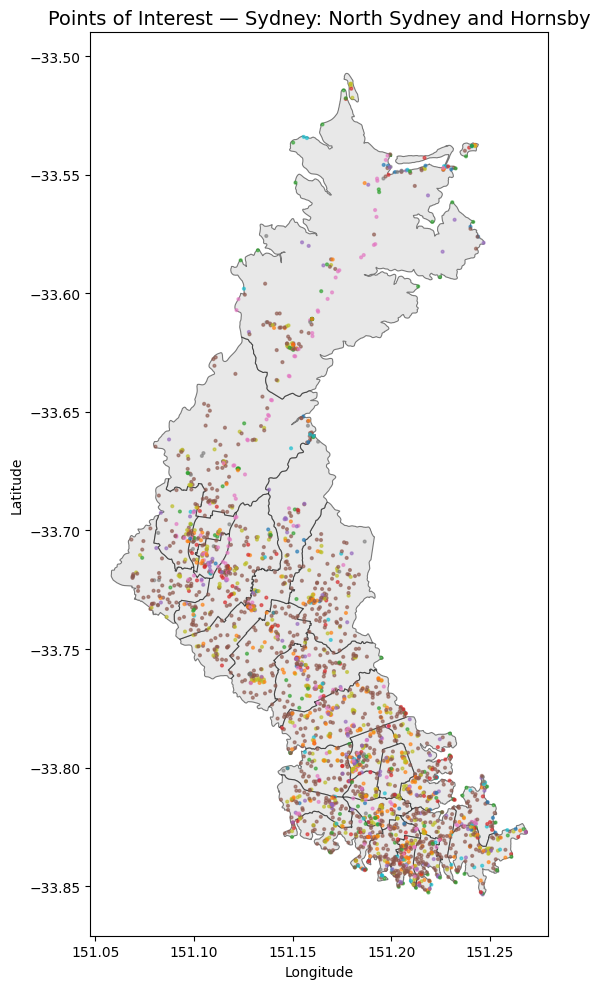

In [74]:
fig, ax = plt.subplots(figsize=(12, 10))

# --- Plot the SA2 boundary polygons ---
sa2_boundaries_spencer.plot(
    ax=ax,
    color="lightgrey",
    edgecolor="black",
    linewidth=0.8,
    alpha=0.5,
)

# --- Convert clean POIs to a GeoDataFrame and plot ---
pois_gdf_spencer = gpd.GeoDataFrame(
    pois_clean_spencer,
    geometry=gpd.points_from_xy(pois_clean_spencer["longitude"], pois_clean_spencer["latitude"]),
    crs="EPSG:4326",
)

pois_gdf_spencer.plot(
    ax=ax,
    column="poitype",
    markersize=4,
    alpha=0.6,
    legend=False,
    legend_kwds={"loc": "upper left", "fontsize": 7, "markerscale": 2},
)

ax.set_title("Points of Interest — Sydney: North Sydney and Hornsby", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

### Arya — Sydney - Baulkam Hills and Hawkesbury

In [75]:
## --- Arya's SA2 boundaries ---
MY_SA4_ARYA = "Sydney - Baulkham Hills and Hawkesbury"
ARYA_TABLE = "points_of_interest_baulkham_hills"
sa2_boundaries_arya = load_sa2_boundaries(MY_SA4_ARYA)

# --- Pull POI data for my region ---
pois_df_arya = fetch_pois_for_zone(sa2_boundaries_arya)
print(f"POI rows collected for {MY_SA4_ARYA}: {len(pois_df_arya):,}")
display(pois_df_arya.head())

# --- Clean columns for database ingestion ---
arya_columns = [
    "SA2_CODE21",
    "SA2_NAME21",
    "SA4_NAME21",
    "poiname",
    "poitype",
    "poigroup",
    "longitude",
    "latitude",
]
pois_clean_arya = pois_df_arya.copy()
for column in arya_columns:
    if column not in pois_clean_arya.columns:
        pois_clean_arya[column] = pd.NA
pois_clean_arya = pois_clean_arya[arya_columns].copy()
pois_clean_arya["longitude"] = pd.to_numeric(pois_clean_arya["longitude"], errors="coerce")
pois_clean_arya["latitude"] = pd.to_numeric(pois_clean_arya["latitude"], errors="coerce")
pois_clean_arya = pois_clean_arya.dropna(
    subset=["SA2_CODE21", "SA2_NAME21", "SA4_NAME21", "longitude", "latitude"]
)
pois_clean_arya = pois_clean_arya.rename(columns={
    "SA2_CODE21": "sa2_code",
    "SA2_NAME21": "sa2_name",
    "SA4_NAME21": "sa4_name",
})

# --- Create my dedicated PostgreSQL/PostGIS table ---
def create_arya_poi_table():
    with get_connection() as conn:
        with conn.cursor() as cur:
            cur.execute("CREATE EXTENSION IF NOT EXISTS postgis;")
            cur.execute(f"DROP TABLE IF EXISTS {ARYA_TABLE};")
            cur.execute(f"""
CREATE TABLE {ARYA_TABLE} (
    id SERIAL PRIMARY KEY,
    sa2_code TEXT NOT NULL,
    sa2_name TEXT NOT NULL,
    sa4_name TEXT NOT NULL,
    poiname TEXT,
    poitype TEXT,
    poigroup TEXT,
    longitude DOUBLE PRECISION NOT NULL,
    latitude DOUBLE PRECISION NOT NULL,
    geom GEOMETRY(Point, 4326),
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);
""")
            cur.execute(f"""
CREATE INDEX idx_{ARYA_TABLE}_geom
ON {ARYA_TABLE} USING GIST (geom);
""")
            cur.execute(f"""
CREATE INDEX idx_{ARYA_TABLE}_sa2
ON {ARYA_TABLE} (sa2_code);
""")
        conn.commit()
    print(f"✓ Table '{ARYA_TABLE}' ready.")

create_arya_poi_table()

# --- Ingest cleaned POIs into my table ---
def ingest_arya_pois(df):
    if df.empty:
        return 0
    rows = [
        (
            row.sa2_code,
            row.sa2_name,
            row.sa4_name,
            row.poiname,
            row.poitype,
            row.poigroup,
            float(row.longitude),
            float(row.latitude),
            float(row.longitude),
            float(row.latitude),
        )
        for row in df.itertuples(index=False)
    ]
    with get_connection() as conn:
        with conn.cursor() as cur:
            from psycopg2.extras import execute_values
            execute_values(cur, f"""
INSERT INTO {ARYA_TABLE}
(sa2_code, sa2_name, sa4_name, poiname, poitype,
 poigroup, longitude, latitude, geom)
VALUES %s
""", rows, template="""
(
    %s, %s, %s, %s, %s, %s, %s, %s,
    ST_SetSRID(ST_MakePoint(%s, %s), 4326))
""")
        conn.commit()
    return len(rows)

n_inserted_arya = ingest_arya_pois(pois_clean_arya)
print(f"✓ {n_inserted_arya:,} POIs ingested into PostgreSQL table '{ARYA_TABLE}'.")

# --- Verify ---
with get_connection() as conn:
    schema_df_arya = pd.read_sql_query("""
        SELECT column_name, data_type, is_nullable
        FROM information_schema.columns
        WHERE table_name = %s
        ORDER BY ordinal_position;
    """, conn, params=(ARYA_TABLE,))

    summary_df_arya = pd.read_sql_query(f"""
        SELECT 
            COUNT(*) AS total_pois, 
            COUNT(DISTINCT sa2_code) AS sa2_regions, 
            COUNT(DISTINCT poitype) AS poi_types, 
            COUNT(DISTINCT poigroup) AS poi_groups 
        FROM {ARYA_TABLE};
    """, conn)

    per_sa2_counts_arya = pd.read_sql_query(f"""
        SELECT sa2_code, sa2_name, COUNT(*) AS total_pois 
        FROM {ARYA_TABLE} 
        GROUP BY sa2_code, sa2_name 
        ORDER BY total_pois DESC, sa2_name;
    """, conn)

    poi_type_counts_arya = pd.read_sql_query(f"""
        SELECT poitype, COUNT(*) AS total_pois 
        FROM {ARYA_TABLE} 
        WHERE poitype IS NOT NULL 
        GROUP BY poitype 
        ORDER BY total_pois DESC, poitype 
        LIMIT 10;
    """, conn)

print(f"\nArya Task 2 database summary:")
display(summary_df_arya)
print("Table schema:")
display(schema_df_arya)
print("POI count by SA2:")
display(per_sa2_counts_arya)
print("Top POI types:")
display(poi_type_counts_arya)

if n_inserted_arya == 0:
    print("⚠ No POIs were ingested. Check your SA2 boundaries and API response.")

Selected SA4: Sydney - Baulkham Hills and Hawkesbury
Number of SA2 regions: 20


,SA2_CODE21,SA2_NAME21,SA4_NAME21,AREASQKM21,bbox
299,115011290,Baulkham Hills - East,Sydney - Baulkham Hills and Hawkesbury,8.3081,"(150.96324051888075, -33.772989884451285, 151...."
300,115011291,Baulkham Hills (West) - Bella Vista,Sydney - Baulkham Hills and Hawkesbury,10.8721,"(150.94329747591232, -33.765544483316226, 150...."
301,115011294,Glenhaven,Sydney - Baulkham Hills and Hawkesbury,7.2309,"(150.96736349800858, -33.716863348091316, 151...."
302,115011296,West Pennant Hills,Sydney - Baulkham Hills and Hawkesbury,7.8291,"(151.00857147345084, -33.76342952936358, 151.0..."
303,115011553,Castle Hill - Central,Sydney - Baulkham Hills and Hawkesbury,4.1512,"(150.9722177418482, -33.74626385603902, 151.00..."


[1/20] Baulkham Hills - East ... loaded 175 POIs from cache
    → kept 110 POIs inside SA2 polygon
[2/20] Baulkham Hills (West) - Bella Vista ... loaded 154 POIs from cache
    → kept 84 POIs inside SA2 polygon
[3/20] Glenhaven ... loaded 91 POIs from cache
    → kept 29 POIs inside SA2 polygon
[4/20] West Pennant Hills ... loaded 97 POIs from cache
    → kept 53 POIs inside SA2 polygon
[5/20] Castle Hill - Central ... loaded 65 POIs from cache
    → kept 19 POIs inside SA2 polygon
[6/20] Castle Hill - East ... loaded 35 POIs from cache
    → kept 27 POIs inside SA2 polygon
[7/20] Castle Hill - North ... loaded 103 POIs from cache
    → kept 74 POIs inside SA2 polygon
[8/20] Castle Hill - South ... loaded 70 POIs from cache
    → kept 39 POIs inside SA2 polygon
[9/20] Castle Hill - West ... loaded 20 POIs from cache
    → kept 10 POIs inside SA2 polygon
[10/20] Cherrybrook ... loaded 87 POIs from cache
    → kept 57 POIs inside SA2 polygon
[11/20] Kellyville - East ... loaded 90 POIs f

,objectid,topoid,poigroup,poitype,poiname,poilabel,poilabeltype,poialtlabel,poisourcefeatureoid,accesscontrol,...,centroidid,shapeuuid,changetype,processstate,urbanity,longitude,latitude,SA2_CODE21,SA2_NAME21,SA4_NAME21
0,1964,500247911,3,Park,HARRY CARR RESERVE,HARRY CARR RESERVE,NAMED,NaN,61,1,...,NaN,9ba2606e-dbb3-3e8a-9ea1-2541ae946719,I,NaN,U,150.985266,-33.758583,115011290,Baulkham Hills - East,Sydney - Baulkham Hills and Hawkesbury
1,1969,500248012,3,Park,NaN,Park,GENERIC,NaN,61,1,...,NaN,d23c2b9a-45e2-38f7-b68c-8f2679034df2,I,NaN,U,151.000665,-33.762313,115011290,Baulkham Hills - East,Sydney - Baulkham Hills and Hawkesbury
2,2047,500254250,3,Sports Field,JASPER OVAL,JASPER OVAL,NAMED,NaN,67,1,...,NaN,f8b0e16e-404b-320d-bcb4-30daf6bbdf40,I,NaN,U,150.981610,-33.756780,115011290,Baulkham Hills - East,Sydney - Baulkham Hills and Hawkesbury
3,2213,500260849,3,Park,GOODEN RESERVE,GOODEN RESERVE,NAMED,NaN,61,1,...,NaN,104f3390-2238-3a06-835e-4c78156fc9f9,M,NaN,U,150.974139,-33.771374,115011290,Baulkham Hills - East,Sydney - Baulkham Hills and Hawkesbury
4,2219,500261082,1,Place Of Worship,NaN,UNITING CHURCH,DERIVED,UNITING,19,1,...,NaN,de28ba8d-1132-38ec-8e76-1c6d6d17479d,I,NaN,U,150.989704,-33.764935,115011290,Baulkham Hills - East,Sydney - Baulkham Hills and Hawkesbury


✓ Table 'points_of_interest_baulkham_hills' ready.
✓ 1,750 POIs ingested into PostgreSQL table 'points_of_interest_baulkham_hills'.

Arya Task 2 database summary:


...

,column_name,data_type,is_nullable
0,id,integer,NO
1,sa2_code,text,NO
2,sa2_name,text,NO
3,sa4_name,text,NO
4,poiname,text,YES
5,poitype,text,YES
6,poigroup,text,YES
7,longitude,double precision,NO
8,latitude,double precision,NO
9,geom,USER-DEFINED,YES


POI count by SA2:


,sa2_code,sa2_name,total_pois
0,115021297,Dural - Kenthurst - Wisemans Ferry,309
1,115031300,Kurrajong Heights - Ebenezer,278
2,115031299,Bilpin - Colo - St Albans,242
3,115011290,Baulkham Hills - East,110
4,115041301,Pitt Town - McGraths Hill,102
5,115021298,Galston - Laughtondale,100
6,115011291,Baulkham Hills (West) - Bella Vista,84
7,115011555,Castle Hill - North,74
8,115041625,Rouse Hill - Beaumont Hills,70
9,115011558,Cherrybrook,57


Top POI types:


,poitype,total_pois
0,Park,456
1,Homestead,154
2,Place Of Worship,73
3,Community Facility,71
4,Sports Field,71
5,Parking Area,65
6,Sports Court,61
7,Primary School,58
8,Firestation - Bush,56
9,Suburb,43


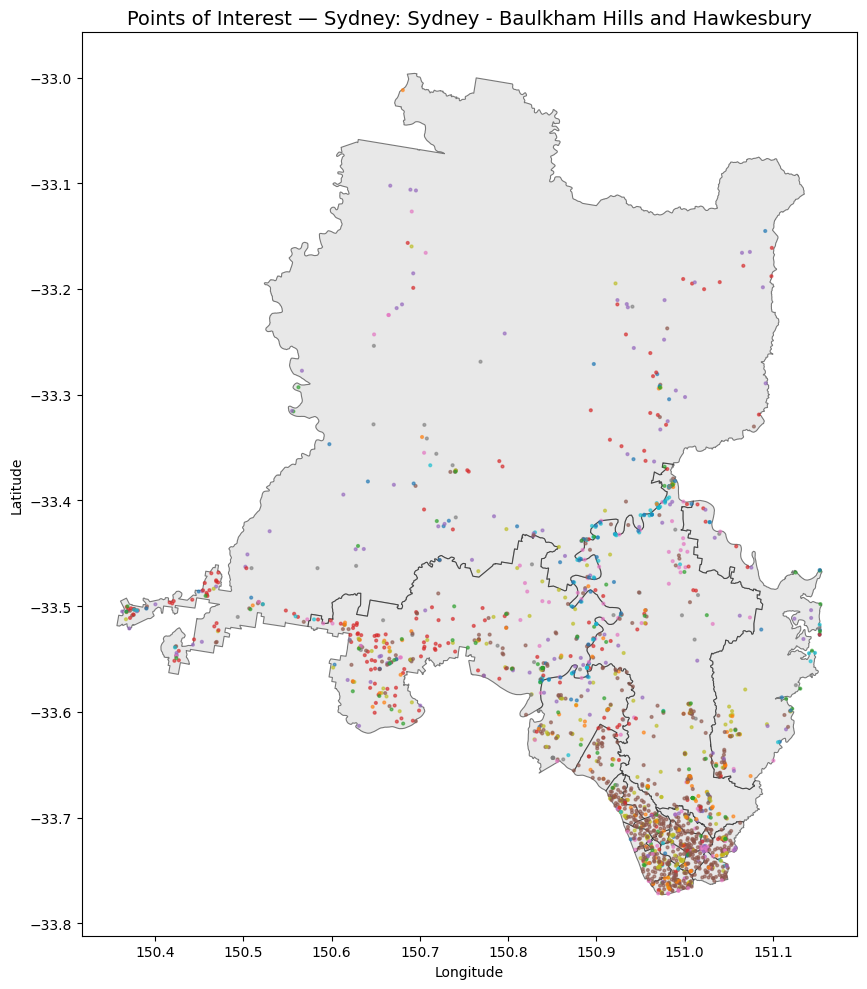

In [76]:
# --- Arya: visualise POIs across my zone ---
fig, ax = plt.subplots(figsize=(12, 10))

# Plot the SA2 boundary polygons
sa2_boundaries_arya.plot(
    ax=ax,
    color="lightgrey",
    edgecolor="black",
    linewidth=0.8,
    alpha=0.5,
)

# Convert clean POIs to a GeoDataFrame and plot
pois_gdf_arya = gpd.GeoDataFrame(
    pois_clean_arya,
    geometry=gpd.points_from_xy(
        pois_clean_arya["longitude"],
        pois_clean_arya["latitude"]
    ),
    crs="EPSG:4326",
)

pois_gdf_arya.plot(
    ax=ax,
    column="poitype",
    markersize=4,
    alpha=0.6,
    legend=False,
    legend_kwds={"loc": "upper left", "fontsize": 7, "markerscale": 2},
)

ax.set_title(f"Points of Interest — Sydney: {MY_SA4_ARYA}", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

# Task 3: SA2 Well-Resourced Score

##  Spencer's code to calculate how "well-resourced" each sa2 region is

In [77]:
population_df = pd.read_csv("SA2_population_data.csv")
population_df = population_df[['Statistical Areas Level 2 2021 code','Statistical Areas Level 2 2021 name', '2021 Estimated resident population (no.)']]
sa2_population = population_df.set_index(
    "Statistical Areas Level 2 2021 code"
    )["2021 Estimated resident population (no.)"].to_dict()

valid_sa2 = []
for sa2 in sa2_population:
    if sa2_population[sa2] >= 100:
        valid_sa2.append(sa2)


In [78]:
# Define weights
poi_weights = {
    # Essential — weight 3
    "General Hospital":           3.0,
    "Primary School":             3.0,
    "High School":                3.0,
    "Combined Primary-Secondary School": 3.0,
    "Police Station":             3.0,
    "Fire Station":               3.0,
    "Firestation - Bush":         3.0,
    "Ambulance Station":          3.0,
    "Special School":             3.0,
    # Community — weight 2
    "Park":                       2.0,
    "Library":                    2.0,
    "Community Medical Centre":   2.0,
    "Community Facility":         2.0,
    "Child Care Centre":          2.0,
    "Retirement Village":         2.0,
    "Nursing Home":               2.0,
    "University":                 2.0,
    "Technical College":          2.0,
    "Swimming Pool Facility":     2.0,
    "Sports Centre":              2.0,
    # Default = 1.0 for everything else
}

In [79]:
dic_spencer = {}
for sa2 in sa2_boundaries_spencer.iterrows():
    code, name = sa2[1].loc["SA2_CODE21"], sa2[1].loc["SA2_NAME21"]
    dic_spencer[name] = 0
    for poi in pois_clean_spencer.iterrows():
        poi_code, poi_type = poi[1].loc["sa2_code"], poi[1].loc["poitype"]
        if poi_code == code:
            if poi_type in poi_weights.keys():
                dic_spencer[name] += poi_weights[poi_type]
            else:
                dic_spencer[name] += 1


In [80]:
weighted_mean_spencer = np.mean(list(dic_spencer.values()))
weighted_std_spencer = np.std(list(dic_spencer.values()))

per_sa2_counts_spencer["zscore"] = (per_sa2_counts_spencer["total_pois"] - per_sa2_counts_spencer["total_pois"].mean()) / per_sa2_counts_spencer["total_pois"].std()
per_sa2_counts_spencer["regular_well_resourced_value"] =  1 / (1 + np.exp(-per_sa2_counts_spencer["zscore"]))

per_sa2_counts_spencer["weighted_score"] = per_sa2_counts_spencer["sa2_name"].map(dic_spencer)
per_sa2_counts_spencer["weighted_zscore"] = per_sa2_counts_spencer["sa2_name"].map(dic_spencer).sub(weighted_mean_spencer).div(weighted_std_spencer)
per_sa2_counts_spencer["weighted_well_resourced_value"] = 1 / (1 + np.exp(-per_sa2_counts_spencer["weighted_zscore"]))

per_sa2_counts_spencer = per_sa2_counts_spencer[per_sa2_counts_spencer["sa2_code"].isin(valid_sa2)]

per_sa2_counts_spencer

,sa2_code,sa2_name,total_pois,zscore,regular_well_resourced_value,weighted_score,weighted_zscore,weighted_well_resourced_value
0,121021404,Berowra - Brooklyn - Cowan,179,2.273886,0.906691,258.0,1.852480,0.864418
1,121031408,Lindfield - Roseville,172,2.092771,0.890199,287.0,2.338651,0.912028
2,121011683,Castle Cove - Northbridge,128,0.954335,0.721986,193.0,0.762786,0.681958
3,121031407,Gordon - Killara,127,0.928462,0.716763,209.0,1.031018,0.737113
4,121031412,Wahroonga (East) - Warrawee,127,0.928462,0.716763,217.0,1.165134,0.762264
5,121031411,Turramurra,124,0.850841,0.700744,197.0,0.829844,0.696322
6,121021403,Asquith - Mount Colah,120,0.747347,0.678600,174.0,0.444260,0.609274
7,121031410,St Ives,119,0.721474,0.672931,213.0,1.098076,0.749899
8,121041417,North Sydney - Lavender Bay,106,0.385118,0.595107,173.0,0.427495,0.605275
9,121031409,Pymble,104,0.333371,0.582579,178.0,0.511318,0.625115


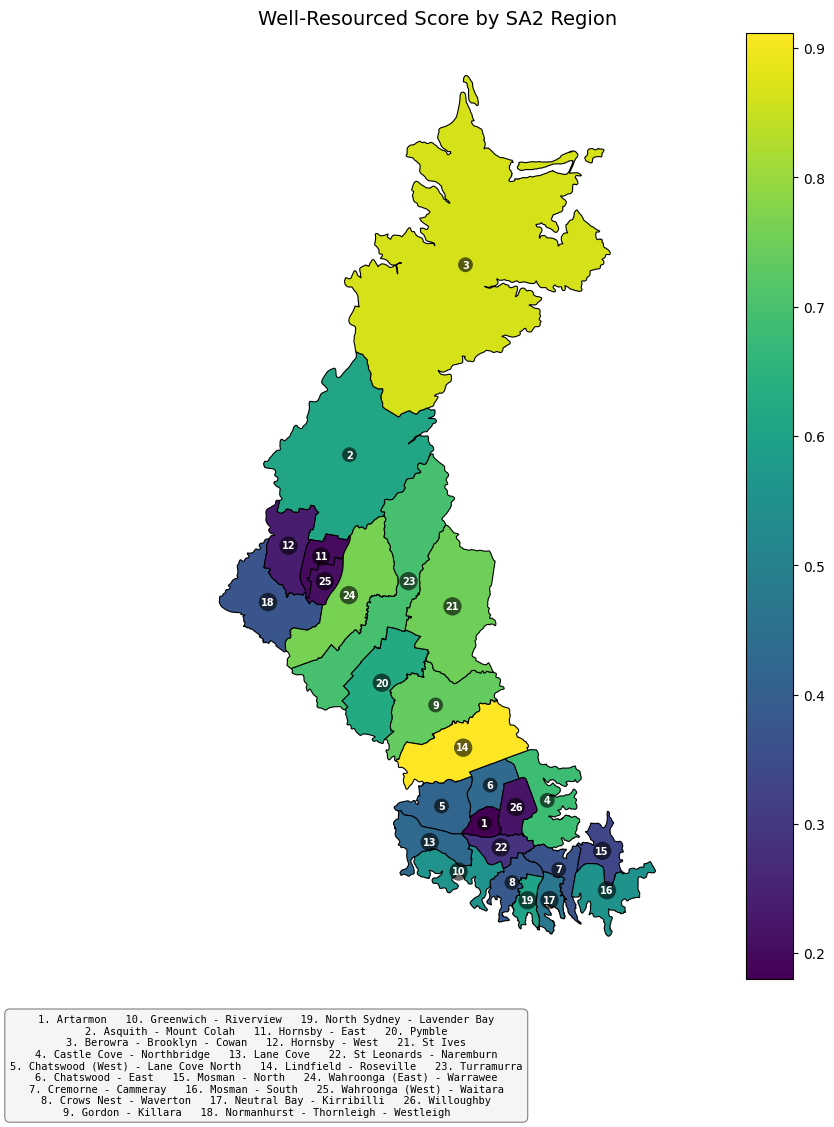

In [81]:
from shapely.geometry import Point

fig, ax = plt.subplots(figsize=(14, 10))

# Merge shapefile with scores
sa2_plot = sa2_boundaries_spencer.merge(
    per_sa2_counts_spencer[["sa2_code", "weighted_well_resourced_value"]],
    left_on="SA2_CODE21",
    right_on="sa2_code",
    how="left"
)

# Plot choropleth
sa2_plot.plot(
    ax=ax,
    column="weighted_well_resourced_value",
    cmap="viridis",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No data"}
)

# Sort regions for consistent numbering (e.g. by name)
sa2_plot = sa2_plot.reset_index(drop=True)
name_col = "SA2_NAME21" if "SA2_NAME21" in sa2_plot.columns else "sa2_code"
sa2_plot_sorted = sa2_plot.sort_values(name_col).reset_index(drop=True)

# Add numbered labels at centroids
for i, row in sa2_plot_sorted.iterrows():
    centroid = row.geometry.centroid
    if i == 22:
        new_x = centroid.x + 0.01
        new_y = centroid.y
        centroid = Point(new_x, new_y)
    number = i + 1
    ax.annotate(
        text=str(number),
        xy=(centroid.x, centroid.y),
        ha="center",
        va="center",
        fontsize=7,
        fontweight="bold",
        color="white",
        bbox=dict(boxstyle="circle,pad=0.25", fc="black", alpha=0.6, lw=0)
    )

ax.set_title("Well-Resourced Score by SA2 Region", fontsize=14)
ax.set_axis_off()

# Build legend table below the map
legend_labels = [
    f"{i + 1}. {row[name_col]}"
    for i, row in sa2_plot_sorted.iterrows()
]

# Split into columns
n_cols = 3
n_rows = -(-len(legend_labels) // n_cols)  # ceiling division
col_chunks = [legend_labels[i * n_rows:(i + 1) * n_rows] for i in range(n_cols)]

# Pad shorter columns
for col in col_chunks:
    while len(col) < n_rows:
        col.append("")

legend_text = "\n".join(
    "   ".join(col_chunks[c][r] for c in range(n_cols))
    for r in range(n_rows)
)

fig.text(
    0.5, -0.02,
    legend_text,
    ha="center",
    va="top",
    fontsize=7.5,
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.5", fc="whitesmoke", ec="grey", lw=0.8)
)

plt.tight_layout()
plt.show()

## Ananya's code to calculate how well resourced an area is

#### Load Population Data

In [82]:
pop_path = Path.cwd() / "ABS_ERP_2001_2023_SA2_1163063899690146738.csv"
pop_df = pd.read_csv(pop_path)

pop_df.columns = pop_df.columns.str.strip()

pop_df = pop_df[[
    "Statistical Areas Level 2 2021 code",
    "Statistical Areas Level 2 2021 name",
    "2021 Estimated resident population (no.)"
]].rename(columns={
    "Statistical Areas Level 2 2021 code":          "sa2_code",
    "Statistical Areas Level 2 2021 name":           "sa2_name_pop",
    "2021 Estimated resident population (no.)":      "population"
})

pop_df["sa2_code"] = pop_df["sa2_code"].astype(str)

print(f"Total SA2s in population data: {len(pop_df)}")
print(pop_df.head())

Total SA2s in population data: 2473
    sa2_code                     sa2_name_pop  population
0  101021007                        Braidwood      4332.0
1  101021008                          Karabar      8548.0
2  101021009                       Queanbeyan     11375.0
3  101021010                Queanbeyan - East      5097.0
4  101021012  Queanbeyan West - Jerrabomberra     12748.0


#### Population Filter (Required)

SA2 regions with fewer than 100 residents are excluded from scoring 
as they do not represent meaningful communities for this analysis.

In [83]:
# --- Count POIs per SA2 from PostgreSQL ---
with get_connection() as conn:
    with conn.cursor() as cur:
        cur.execute("""
            SELECT sa2_code,
                   sa2_name,
                   sa4_name,
                   COUNT(*) AS poi_count
            FROM points_of_interest
            WHERE sa4_name = %s
            GROUP BY sa2_code, sa2_name, sa4_name
            ORDER BY poi_count DESC;
        """, (MY_SA4_ANANYA,))
        rows = cur.fetchall()
        cols = [desc[0] for desc in cur.description]

poi_counts = pd.DataFrame(rows, columns=cols)
poi_counts["sa2_code"] = poi_counts["sa2_code"].astype(str)

# --- Merge with population ---
poi_counts = poi_counts.merge(
    pop_df[["sa2_code", "population"]],
    on="sa2_code",
    how="left"
)

# --- Apply population filter ---
before = len(poi_counts)
poi_counts = poi_counts[poi_counts["population"] >= 100].copy().reset_index(drop=True)
after = len(poi_counts)

print(f"SA2s before population filter: {before}")
print(f"SA2s after population filter:  {after}")
print(f"SA2s removed:                  {before - after}")
print()
print(poi_counts[["sa2_name", "population", "poi_count"]].to_string(index=False))

SA2s before population filter: 24
SA2s after population filter:  23
SA2s removed:                  1

                     sa2_name  population  poi_count
     Rooty Hill - Minchinbury     22990.0        762
   Lalor Park - Kings Langley     25568.0        672
        Mount Druitt - Whalan     23182.0        660
Blacktown (East) - Kings Park     17188.0        618
Bidwill - Hebersham - Emerton     18740.0        558
       Seven Hills - Prospect     14929.0        498
         Doonside - Woodcroft     23605.0        486
                   Riverstone     13949.0        414
    Lethbridge Park - Tregear     21873.0        396
     Hassall Grove - Plumpton     21576.0        378
 Blacktown (North) - Marayong     20746.0        360
             Blacktown - West     17245.0        342
                 Quakers Hill     24879.0        324
      Glendenning - Dean Park      8415.0        252
                     Glenwood     15876.0        240
            Schofields - East     25363.0        2

####  Basic Score Calculation (Required)

For each SA2 we compute a well-resourced score using the formula:

**Score = S(z_POI)**

where:
- **x** = raw POI count for this SA2 (counted via SQL GROUP BY)
- **μ** = mean POI count across all SA2s in the SA4
- **σ** = standard deviation of POI counts across all SA2s in the SA4
- **z = (x − μ) / σ** (normalised z-score)
- **S(z) = 1 / (1 + e^(−z))** (sigmoid function)

A score above 0.5 means the SA2 is better resourced than average.
A score below 0.5 means it is below average.

In [84]:
# --- Sigmoid function ---
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# --- Basic z-score using mean and std ---
x     = poi_counts["poi_count"]
mu    = x.mean()
sigma = x.std()

print(f"Mean POI count (μ):  {mu:.2f}")
print(f"Std deviation (σ):   {sigma:.2f}")

poi_counts["z_basic"]     = (x - mu) / sigma
poi_counts["score_basic"] = sigmoid(poi_counts["z_basic"])

# --- Results ---
basic_results = poi_counts[["sa2_name", "population", "poi_count", "z_basic", "score_basic"]] \
    .sort_values("score_basic", ascending=False) \
    .reset_index(drop=True)

basic_results.index += 1  # rank from 1

print("\nBasic Well-Resourced Scores — Sydney - Blacktown")
print(basic_results.to_string())

Mean POI count (μ):  356.61
Std deviation (σ):   201.16

Basic Well-Resourced Scores — Sydney - Blacktown
                         sa2_name  population  poi_count   z_basic  score_basic
1        Rooty Hill - Minchinbury     22990.0        762  2.015234     0.882387
2      Lalor Park - Kings Langley     25568.0        672  1.567837     0.827475
3           Mount Druitt - Whalan     23182.0        660  1.508184     0.818792
4   Blacktown (East) - Kings Park     17188.0        618  1.299398     0.785734
5   Bidwill - Hebersham - Emerton     18740.0        558  1.001133     0.731281
6          Seven Hills - Prospect     14929.0        498  0.702868     0.668823
7            Doonside - Woodcroft     23605.0        486  0.643215     0.655480
8                      Riverstone     13949.0        414  0.285297     0.570844
9       Lethbridge Park - Tregear     21873.0        396  0.195817     0.548799
10       Hassall Grove - Plumpton     21576.0        378  0.106338     0.526559
11   Blacktown

#### Extension 1 — Robust Z-Score (Median + IQR)

**Justification:** The mean (μ) is sensitive to outliers. A single SA2 with 
an unusually high POI count inflates μ, compressing scores for all other SA2s 
toward 0.5. To mitigate this we replace:
- **μ → median** (the middle value, unaffected by extremes)
- **σ → IQR** (interquartile range = Q75 − Q25, a robust measure of spread)

This gives a fairer score distribution when outliers are present.

In [85]:
median = x.median()
iqr    = x.quantile(0.75) - x.quantile(0.25)

print(f"Median POI count: {median:.2f}")
print(f"IQR:              {iqr:.2f}")

poi_counts["z_robust"]     = (x - median) / iqr
poi_counts["score_robust"] = sigmoid(poi_counts["z_robust"])

robust_results = poi_counts[["sa2_name", "poi_count", "z_robust", "score_robust"]] \
    .sort_values("score_robust", ascending=False) \
    .reset_index(drop=True)

robust_results.index += 1
print("\nRobust Scores — Sydney - Blacktown")
print(robust_results.to_string())

Median POI count: 342.00
IQR:              285.00

Robust Scores — Sydney - Blacktown
                         sa2_name  poi_count  z_robust  score_robust
1        Rooty Hill - Minchinbury        762  1.473684      0.813617
2      Lalor Park - Kings Langley        672  1.157895      0.760950
3           Mount Druitt - Whalan        660  1.115789      0.753207
4   Blacktown (East) - Kings Park        618  0.968421      0.724805
5   Bidwill - Hebersham - Emerton        558  0.757895      0.680896
6          Seven Hills - Prospect        498  0.547368      0.633525
7            Doonside - Woodcroft        486  0.505263      0.623695
8                      Riverstone        414  0.252632      0.562824
9       Lethbridge Park - Tregear        396  0.189474      0.547227
10       Hassall Grove - Plumpton        378  0.126316      0.531537
11   Blacktown (North) - Marayong        360  0.063158      0.515784
12               Blacktown - West        342  0.000000      0.500000
13               

####  Extension 2 — Weighted POI Types

**Justification:** Not all POIs contribute equally to how well-resourced an 
area is. A hospital or school has a far greater impact on community welfare 
than a car park or monument. We assign weights to each `poitype`:

| Weight | Category | POI Types |
|--------|----------|-----------|
| 3.0 | Essential services | Hospital, School, Police, Fire, Ambulance |
| 2.0 | Community services | Park, Library, Medical Centre, Childcare, Aged Care |
| 1.0 | Other | Everything else |

The weighted POI count replaces the raw count as our variable x.

In [86]:
# Define weights
poi_weights = {
    # Essential — weight 3
    "General Hospital":           3.0,
    "Primary School":             3.0,
    "High School":                3.0,
    "Combined Primary-Secondary School": 3.0,
    "Police Station":             3.0,
    "Fire Station":               3.0,
    "Firestation - Bush":         3.0,
    "Ambulance Station":          3.0,
    "Special School":             3.0,
    # Community — weight 2
    "Park":                       2.0,
    "Library":                    2.0,
    "Community Medical Centre":   2.0,
    "Community Facility":         2.0,
    "Child Care Centre":          2.0,
    "Retirement Village":         2.0,
    "Nursing Home":               2.0,
    "University":                 2.0,
    "Technical College":          2.0,
    "Swimming Pool Facility":     2.0,
    "Sports Centre":              2.0,
    # Default = 1.0 for everything else
}

# Fetch individual POIs with their types
with get_connection() as conn:
    with conn.cursor() as cur:
        cur.execute("""
            SELECT sa2_code, sa2_name, poitype
            FROM points_of_interest
            WHERE sa4_name = %s;
        """, (MY_SA4_ANANYA,))
        poi_rows = cur.fetchall()

poi_detail_df = pd.DataFrame(poi_rows, columns=["sa2_code", "sa2_name", "poitype"])
poi_detail_df["sa2_code"] = poi_detail_df["sa2_code"].astype(str)
poi_detail_df["weight"]   = poi_detail_df["poitype"].map(poi_weights).fillna(1.0)

# Weighted count per SA2
weighted_counts = poi_detail_df.groupby(
    ["sa2_code", "sa2_name"]
)["weight"].sum().reset_index().rename(columns={"weight": "weighted_poi_count"})

poi_counts = poi_counts.merge(weighted_counts, on=["sa2_code", "sa2_name"], how="left")
poi_counts["weighted_poi_count"] = poi_counts["weighted_poi_count"].fillna(0)

w                          = poi_counts["weighted_poi_count"]
poi_counts["z_weighted"]   = (w - w.mean()) / w.std()
poi_counts["score_weighted"] = sigmoid(poi_counts["z_weighted"])

weighted_results = poi_counts[["sa2_name", "poi_count", "weighted_poi_count", "score_weighted"]] \
    .sort_values("score_weighted", ascending=False) \
    .reset_index(drop=True)

weighted_results.index += 1
print("Weighted POI Scores — Sydney - Blacktown")
print(weighted_results.to_string())

Weighted POI Scores — Sydney - Blacktown
                         sa2_name  poi_count  weighted_poi_count  score_weighted
1      Lalor Park - Kings Langley        672              1170.0        0.858487
2        Rooty Hill - Minchinbury        762              1134.0        0.844271
3           Mount Druitt - Whalan        660              1056.0        0.809503
4   Bidwill - Hebersham - Emerton        558              1002.0        0.782136
5   Blacktown (East) - Kings Park        618               930.0        0.741411
6            Doonside - Woodcroft        486               768.0        0.633540
7          Seven Hills - Prospect        498               744.0        0.615972
8       Lethbridge Park - Tregear        396               744.0        0.615972
9                      Riverstone        414               702.0        0.584514
10       Hassall Grove - Plumpton        378               678.0        0.566205
11               Blacktown - West        342               618.0    

#### 3.7 Final Score

Our final score combines Extension 1 (robust statistics) and Extension 3 
(weighted POI types) — using median and IQR on weighted POI counts. This 
gives the most meaningful measure of how well-resourced each SA2 is by:
- Reducing outlier influence (median + IQR)
- Reflecting community importance of different POI types (weights)
- Excluding non-communities (population < 100)

In [87]:
w      = poi_counts["weighted_poi_count"]
median = w.median()
iqr    = w.quantile(0.75) - w.quantile(0.25)

poi_counts["z_final"]     = (w - median) / iqr
poi_counts["score_final"] = sigmoid(poi_counts["z_final"])

final_table = poi_counts[[
    "sa2_name", "population", "poi_count",
    "weighted_poi_count", "z_final", "score_final"
]].sort_values("score_final", ascending=False).reset_index(drop=True)

final_table.index += 1
print("Final Well-Resourced Scores — Sydney - Blacktown")
print(final_table.to_string())

# --- Save to PostgreSQL ---
with get_connection() as conn:
    with conn.cursor() as cur:
        cur.execute("DROP TABLE IF EXISTS sa2_scores;")
        cur.execute("""
            CREATE TABLE sa2_scores (
                sa2_code            TEXT PRIMARY KEY,
                sa2_name            TEXT,
                sa4_name            TEXT,
                population          DOUBLE PRECISION,
                poi_count           INT,
                weighted_poi_count  DOUBLE PRECISION,
                z_final             DOUBLE PRECISION,
                score_final         DOUBLE PRECISION
            );
        """)
        for _, row in poi_counts.iterrows():
            cur.execute("""
                INSERT INTO sa2_scores VALUES (%s,%s,%s,%s,%s,%s,%s,%s)
                ON CONFLICT DO NOTHING;
            """, (
                row["sa2_code"],
                row["sa2_name"],
                MY_SA4_ANANYA,
                row["population"],
                int(row["poi_count"]),
                row["weighted_poi_count"],
                row["z_final"],
                row["score_final"],
            ))
    conn.commit()
print("✓ Final scores saved to sa2_scores table in PostgreSQL.")

Final Well-Resourced Scores — Sydney - Blacktown
                         sa2_name  population  poi_count  weighted_poi_count   z_final  score_final
1      Lalor Park - Kings Langley     25568.0        672              1170.0  1.357143     0.795295
2        Rooty Hill - Minchinbury     22990.0        762              1134.0  1.271429     0.780987
3           Mount Druitt - Whalan     23182.0        660              1056.0  1.085714     0.747574
4   Bidwill - Hebersham - Emerton     18740.0        558              1002.0  0.957143     0.722549
5   Blacktown (East) - Kings Park     17188.0        618               930.0  0.785714     0.686910
6            Doonside - Woodcroft     23605.0        486               768.0  0.400000     0.598688
7          Seven Hills - Prospect     14929.0        498               744.0  0.342857     0.584884
8       Lethbridge Park - Tregear     21873.0        396               744.0  0.342857     0.584884
9                      Riverstone     13949.0      

###  Map Overlay — Sydney - Blacktown

In [88]:
import matplotlib.pyplot as plt
import geopandas as gpd
from pathlib import Path

# --- Load SA2 boundaries and merge with scores ---
shp_path = Path.cwd() / "SA2_2021_AUST_GDA2020.shp"
sa2_gdf = gpd.read_file(shp_path).to_crs("EPSG:4326")
blacktown_gdf = sa2_gdf[sa2_gdf["SA4_NAME21"] == "Sydney - Blacktown"].copy()
blacktown_gdf["SA2_CODE21"] = blacktown_gdf["SA2_CODE21"].astype(str)

map_gdf = blacktown_gdf.merge(
    scores_df[["sa2_code", "score_final", "poi_count"]],
    left_on="SA2_CODE21",
    right_on="sa2_code",
    how="left"
)

# --- Map ---
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

map_gdf.plot(
    column="score_final",
    cmap="RdYlBu",
    linewidth=0.5,
    edgecolor="white",
    legend=True,
    legend_kwds={"label": "Well-Resourced Score", "shrink": 0.7},
    missing_kwds={"color": "lightgrey", "label": "No data"},
    ax=ax,
    vmin=0, vmax=1
)

# SA2 labels with score
for _, row in map_gdf.iterrows():
    if row.geometry is not None and not pd.isna(row.get("score_final")):
        centroid = row.geometry.centroid
        ax.annotate(
            f'{row["SA2_NAME21"]}',
            xy=(centroid.x, centroid.y),
            fontsize=5.5, ha="center", va="center", color="black"
        )

ax.set_title("Well-Resourced Score Map — Sydney - Blacktown\n(Blue = high, Red = low)",
             fontsize=13, fontweight="bold")
ax.set_axis_off()

plt.tight_layout()
plt.savefig("blacktown_score_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Blacktown map overlay saved.")

NameError: name 'scores_df' is not defined

## Ronnie — Sydney - Parramatta Scores

This section applies the same scoring method used above to Ronnie's selected SA4 zone and appends the results to the shared `sa2_scores` table used by Task 4.


In [15]:
# --- Ronnie: append Sydney - Parramatta scores to shared sa2_scores table ---
MY_SA4_RONNIE = "Sydney - Parramatta"
RONNIE_POI_TABLE = "points_of_interest_parramatta"

# Count POIs per SA2 from Ronnie's PostgreSQL/PostGIS table.
with get_connection() as conn:
    with conn.cursor() as cur:
        cur.execute(f"""
            SELECT sa2_code,
                   sa2_name,
                   sa4_name,
                   COUNT(*) AS poi_count
            FROM {RONNIE_POI_TABLE}
            WHERE sa4_name = %s
            GROUP BY sa2_code, sa2_name, sa4_name
            ORDER BY poi_count DESC;
        """, (MY_SA4_RONNIE,))
        rows = cur.fetchall()
        cols = [desc[0] for desc in cur.description]

ronnie_scores_df = pd.DataFrame(rows, columns=cols)
ronnie_scores_df["sa2_code"] = ronnie_scores_df["sa2_code"].astype(str)

# Merge with population and exclude SA2s with fewer than 100 residents.
ronnie_scores_df = ronnie_scores_df.merge(
    pop_df[["sa2_code", "population"]],
    on="sa2_code",
    how="left",
)

before = len(ronnie_scores_df)
ronnie_scores_df = ronnie_scores_df[ronnie_scores_df["population"] >= 100].copy().reset_index(drop=True)
after = len(ronnie_scores_df)

print(f"Ronnie SA2s before population filter: {before}")
print(f"Ronnie SA2s after population filter:  {after}")
print(f"Ronnie SA2s removed:                  {before - after}")

# Fetch individual POIs and apply the shared POI weights.
with get_connection() as conn:
    with conn.cursor() as cur:
        cur.execute(f"""
            SELECT sa2_code, sa2_name, poitype
            FROM {RONNIE_POI_TABLE}
            WHERE sa4_name = %s;
        """, (MY_SA4_RONNIE,))
        poi_rows = cur.fetchall()

ronnie_poi_detail_df = pd.DataFrame(poi_rows, columns=["sa2_code", "sa2_name", "poitype"])
ronnie_poi_detail_df["sa2_code"] = ronnie_poi_detail_df["sa2_code"].astype(str)
ronnie_poi_detail_df["weight"] = ronnie_poi_detail_df["poitype"].map(poi_weights).fillna(1.0)

ronnie_weighted_counts = ronnie_poi_detail_df.groupby(
    ["sa2_code", "sa2_name"]
)["weight"].sum().reset_index().rename(columns={"weight": "weighted_poi_count"})

ronnie_scores_df = ronnie_scores_df.merge(
    ronnie_weighted_counts,
    on=["sa2_code", "sa2_name"],
    how="left",
)
ronnie_scores_df["weighted_poi_count"] = ronnie_scores_df["weighted_poi_count"].fillna(0)

# Final score: robust z-score on weighted POI count, matching Ananya's final method.
w = ronnie_scores_df["weighted_poi_count"]
median = w.median()
iqr = w.quantile(0.75) - w.quantile(0.25)

if iqr == 0 or pd.isna(iqr):
    ronnie_scores_df["z_final"] = 0
else:
    ronnie_scores_df["z_final"] = (w - median) / iqr

ronnie_scores_df["score_final"] = sigmoid(ronnie_scores_df["z_final"])

ronnie_final_table = ronnie_scores_df[[
    "sa2_code", "sa2_name", "sa4_name", "population",
    "poi_count", "weighted_poi_count", "z_final", "score_final"
]].sort_values("score_final", ascending=False).reset_index(drop=True)

ronnie_final_table.index += 1
print("Final Well-Resourced Scores — Sydney - Parramatta")
print(ronnie_final_table.to_string())

# Append Ronnie scores to the shared table used by Task 4.
with get_connection() as conn:
    with conn.cursor() as cur:
        cur.execute("""
            CREATE TABLE IF NOT EXISTS sa2_scores (
                sa2_code            TEXT PRIMARY KEY,
                sa2_name            TEXT,
                sa4_name            TEXT,
                population          DOUBLE PRECISION,
                poi_count           INT,
                weighted_poi_count  DOUBLE PRECISION,
                z_final             DOUBLE PRECISION,
                score_final         DOUBLE PRECISION
            );
        """)
        cur.execute("DELETE FROM sa2_scores WHERE sa4_name = %s;", (MY_SA4_RONNIE,))
        for _, row in ronnie_scores_df.iterrows():
            cur.execute("""
                INSERT INTO sa2_scores VALUES (%s,%s,%s,%s,%s,%s,%s,%s)
                ON CONFLICT (sa2_code) DO UPDATE SET
                    sa2_name = EXCLUDED.sa2_name,
                    sa4_name = EXCLUDED.sa4_name,
                    population = EXCLUDED.population,
                    poi_count = EXCLUDED.poi_count,
                    weighted_poi_count = EXCLUDED.weighted_poi_count,
                    z_final = EXCLUDED.z_final,
                    score_final = EXCLUDED.score_final;
            """, (
                row["sa2_code"],
                row["sa2_name"],
                row["sa4_name"],
                row["population"],
                int(row["poi_count"]),
                row["weighted_poi_count"],
                row["z_final"],
                row["score_final"],
            ))
    conn.commit()

print("✓ Ronnie scores appended to shared sa2_scores table in PostgreSQL.")


Ronnie SA2s before population filter: 34
Ronnie SA2s after population filter:  31
Ronnie SA2s removed:                  3


NameError: name 'np' is not defined

## Arya: Sydney - Baulkham Hills and Hawkesbury Scores

In [90]:
# --- Arya: append Sydney - Baulkham Hills and Hawkesbury scores to shared sa2_scores table ---
MY_SA4_ARYA = "Sydney - Baulkham Hills and Hawkesbury"
ARYA_POI_TABLE = "points_of_interest_baulkham_hills"

# Count POIs per SA2 from Arya's PostgreSQL/PostGIS table.
with get_connection() as conn:
    with conn.cursor() as cur:
        cur.execute(f"""
            SELECT sa2_code,
                   sa2_name,
                   sa4_name,
                   COUNT(*) AS poi_count
            FROM {ARYA_POI_TABLE}
            WHERE sa4_name = %s
            GROUP BY sa2_code, sa2_name, sa4_name
            ORDER BY poi_count DESC;
        """, (MY_SA4_ARYA,))
        rows = cur.fetchall()
        cols = [desc[0] for desc in cur.description]

arya_scores_df = pd.DataFrame(rows, columns=cols)
arya_scores_df["sa2_code"] = arya_scores_df["sa2_code"].astype(str)

# Merge with population and exclude SA2s with fewer than 100 residents.
arya_scores_df = arya_scores_df.merge(
    pop_df[["sa2_code", "population"]],
    on="sa2_code",
    how="left",
)

before = len(arya_scores_df)
arya_scores_df = arya_scores_df[arya_scores_df["population"] >= 100].copy().reset_index(drop=True)
after = len(arya_scores_df)

print(f"Arya SA2s before population filter: {before}")
print(f"Arya SA2s after population filter:  {after}")
print(f"Arya SA2s removed:                  {before - after}")

# Fetch individual POIs and apply the shared POI weights.
with get_connection() as conn:
    with conn.cursor() as cur:
        cur.execute(f"""
            SELECT sa2_code, sa2_name, poitype
            FROM {ARYA_POI_TABLE}
            WHERE sa4_name = %s;
        """, (MY_SA4_ARYA,))
        poi_rows = cur.fetchall()

arya_poi_detail_df = pd.DataFrame(poi_rows, columns=["sa2_code", "sa2_name", "poitype"])
arya_poi_detail_df["sa2_code"] = arya_poi_detail_df["sa2_code"].astype(str)
arya_poi_detail_df["weight"] = arya_poi_detail_df["poitype"].map(poi_weights).fillna(1.0)

arya_weighted_counts = arya_poi_detail_df.groupby(
    ["sa2_code", "sa2_name"]
)["weight"].sum().reset_index().rename(columns={"weight": "weighted_poi_count"})

arya_scores_df = arya_scores_df.merge(
    arya_weighted_counts,
    on=["sa2_code", "sa2_name"],
    how="left",
)
arya_scores_df["weighted_poi_count"] = arya_scores_df["weighted_poi_count"].fillna(0)

# Final score: robust z-score on weighted POI count, matching Ananya's final method.
w = arya_scores_df["weighted_poi_count"]
median = w.median()
iqr = w.quantile(0.75) - w.quantile(0.25)

if iqr == 0 or pd.isna(iqr):
    arya_scores_df["z_final"] = 0
else:
    arya_scores_df["z_final"] = (w - median) / iqr

arya_scores_df["score_final"] = sigmoid(arya_scores_df["z_final"])

arya_final_table = arya_scores_df[[
    "sa2_code", "sa2_name", "sa4_name", "population",
    "poi_count", "weighted_poi_count", "z_final", "score_final"
]].sort_values("score_final", ascending=False).reset_index(drop=True)

arya_final_table.index += 1
print("Final Well-Resourced Scores — Sydney - Baulkham Hills and Hawkesbury")
print(arya_final_table.to_string())

# Append Arya scores to the shared table used by Task 4.
with get_connection() as conn:
    with conn.cursor() as cur:
        cur.execute("""
            CREATE TABLE IF NOT EXISTS sa2_scores (
                sa2_code            TEXT PRIMARY KEY,
                sa2_name            TEXT,
                sa4_name            TEXT,
                population          DOUBLE PRECISION,
                poi_count           INT,
                weighted_poi_count  DOUBLE PRECISION,
                z_final             DOUBLE PRECISION,
                score_final         DOUBLE PRECISION
            );
        """)
        cur.execute("DELETE FROM sa2_scores WHERE sa4_name = %s;", (MY_SA4_ARYA,))
        for _, row in arya_scores_df.iterrows():
            cur.execute("""
                INSERT INTO sa2_scores VALUES (%s,%s,%s,%s,%s,%s,%s,%s)
                ON CONFLICT (sa2_code) DO UPDATE SET
                    sa2_name = EXCLUDED.sa2_name,
                    sa4_name = EXCLUDED.sa4_name,
                    population = EXCLUDED.population,
                    poi_count = EXCLUDED.poi_count,
                    weighted_poi_count = EXCLUDED.weighted_poi_count,
                    z_final = EXCLUDED.z_final,
                    score_final = EXCLUDED.score_final;
            """, (
                row["sa2_code"],
                row["sa2_name"],
                row["sa4_name"],
                row["population"],
                int(row["poi_count"]),
                row["weighted_poi_count"],
                row["z_final"],
                row["score_final"],
            ))
    conn.commit()

print("✓ Arya scores appended to shared sa2_scores table in PostgreSQL.")

Arya SA2s before population filter: 20
Arya SA2s after population filter:  20
Arya SA2s removed:                  0
Final Well-Resourced Scores — Sydney - Baulkham Hills and Hawkesbury
     sa2_code                             sa2_name                                sa4_name  population  poi_count  weighted_poi_count   z_final  score_final
1   115021297   Dural - Kenthurst - Wisemans Ferry  Sydney - Baulkham Hills and Hawkesbury     22596.0        309               465.0  4.245614     0.985875
2   115031300         Kurrajong Heights - Ebenezer  Sydney - Baulkham Hills and Hawkesbury     22302.0        278               387.0  3.333333     0.965555
3   115031299            Bilpin - Colo - St Albans  Sydney - Baulkham Hills and Hawkesbury      2852.0        242               293.0  2.233918     0.903254
4   115011290                Baulkham Hills - East  Sydney - Baulkham Hills and Hawkesbury     24862.0        110               176.0  0.865497     0.703808
5   115011291  Baulkham Hills 

Map Overlay - Baulkham Hills and Hawkesbury

In [ ]:
from shapely.geometry import Point

fig, ax = plt.subplots(figsize=(14, 10))

# Merge shapefile with Arya's final scores
arya_map = sa2_boundaries_arya.merge(
    arya_final_table[["sa2_code", "score_final"]],
    left_on="SA2_CODE21",
    right_on="sa2_code",
    how="left"
)

# Plot choropleth
arya_map.plot(
    ax=ax,
    column="score_final",
    cmap="viridis",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No data"}
)

# Sort regions for consistent numbering
arya_map = arya_map.reset_index(drop=True)
name_col = "SA2_NAME21" if "SA2_NAME21" in arya_map.columns else "sa2_code"
arya_map_sorted = arya_map.sort_values(name_col).reset_index(drop=True)

# Add numbered labels at centroids
for i, row in arya_map_sorted.iterrows():
    centroid = row.geometry.centroid
    if i == 22:
        centroid = Point(centroid.x + 0.01, centroid.y)
    number = i + 1
    ax.annotate(
        text=str(number),
        xy=(centroid.x, centroid.y),
        ha="center",
        va="center",
        fontsize=7,
        fontweight="bold",
        color="white",
        bbox=dict(boxstyle="circle,pad=0.25", fc="black", alpha=0.6, lw=0)
    )

ax.set_title("Well-Resourced Score by SA2 Region — Sydney - Baulkham Hills and Hawkesbury", fontsize=14)
ax.set_axis_off()

# Build legend table below the map
legend_labels = [
    f"{i + 1}. {row[name_col]}"
    for i, row in arya_map_sorted.iterrows()
]

# Split into columns
n_cols = 3
n_rows = -(-len(legend_labels) // n_cols)
col_chunks = [legend_labels[i * n_rows:(i + 1) * n_rows] for i in range(n_cols)]

# Pad shorter columns
for col in col_chunks:
    while len(col) < n_rows:
        col.append("")

legend_text = "\n".join(
    "   ".join(col_chunks[c][r] for c in range(n_cols))
    for r in range(n_rows)
)

fig.text(
    0.5, -0.02,
    legend_text,
    ha="center",
    va="top",
    fontsize=7.5,
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.5", fc="whitesmoke", ec="grey", lw=0.8)
)

plt.tight_layout()
plt.show()

Add Spencer's data into the grouped database.

In [95]:
with get_connection() as conn:
    with conn.cursor() as cur:
        cur.execute("DELETE FROM sa2_scores WHERE sa4_name = %s;", (MY_SA4_SPENCER,))
        for _, row in per_sa2_counts_spencer.iterrows():
            cur.execute("""
                INSERT INTO sa2_scores VALUES (%s,%s,%s,%s,%s,%s,%s,%s)
                ON CONFLICT (sa2_code) DO UPDATE SET
                    sa2_name           = EXCLUDED.sa2_name,
                    sa4_name           = EXCLUDED.sa4_name,
                    population         = EXCLUDED.population,
                    poi_count          = EXCLUDED.poi_count,
                    weighted_poi_count = EXCLUDED.weighted_poi_count,
                    z_final            = EXCLUDED.z_final,
                    score_final        = EXCLUDED.score_final;
            """, (
                str(row["sa2_code"]),
                row["sa2_name"],
                MY_SA4_SPENCER,
                None,
                int(row["total_pois"]),
                row["weighted_score"],
                row["weighted_zscore"],
                row["weighted_well_resourced_value"],
            ))
    conn.commit()

## Scoring Explanation Notes

POI count is used as a proxy for resource availability because the NSW Points of Interest dataset records facilities and places that residents may use, such as schools, parks, medical facilities, community facilities, transport-related places, and emergency services. A higher number of relevant POIs suggests that an SA2 has more nearby services and amenities.

We apply z-score normalisation because raw POI counts are not directly comparable across SA2s. Some areas naturally have more POIs than others, so the z-score measures whether an SA2 is above or below the average for the selected zones.

The sigmoid function converts the z-score into a score between 0 and 1. This makes the final well-resourced score easier to interpret: values above 0.5 are above average, values below 0.5 are below average, and values closer to 1 indicate stronger relative resource availability.

SA2 regions with population below 100 are excluded because very small populations may not represent meaningful residential communities. Including them could distort the results, especially where a region has many POIs but very few residents.

We extend the basic formula by using weighted POI counts. Essential services such as hospitals, schools, police, fire, and ambulance facilities are given higher weight than general POIs, because they contribute more directly to community wellbeing. Community services such as parks, libraries, childcare, aged care, and sports centres are also weighted above default POIs. All other POI types receive a default weight of 1.

We also use a robust z-score based on the median and interquartile range for the final score. This reduces the influence of outliers, where one SA2 may contain an unusually high number of POIs. The final score is therefore calculated from the weighted POI count using robust normalisation and sigmoid scaling.


# Task 4: Report Analysis and Visualisation

## 4.1 Summary of Key Findings 

Key statistics from the NSW Region Summary dataset are reproduced here.
Full written analysis is provided in the PDF report.

## 4.2 Intra-Zone Score Distribution

For each SA4 zone, we examine how scores are distributed across its SA2 
regions, revealing whether some zones have more internal inequality than others.

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import numpy as np
import pandas as pd
from pathlib import Path

# --- Load all scores from PostgreSQL ---
with get_connection() as conn:
    with conn.cursor() as cur:
        cur.execute("""
            SELECT sa2_code, sa2_name, sa4_name, population,
                   poi_count, weighted_poi_count, z_final, score_final
            FROM sa2_scores
            ORDER BY sa4_name, score_final DESC;
        """)
        rows = cur.fetchall()
        cols = [desc[0] for desc in cur.description]

all_scores_df = pd.DataFrame(rows, columns=cols)
all_scores_df["sa2_code"] = all_scores_df["sa2_code"].astype(str)

print(f"Total SA2 regions loaded: {len(all_scores_df)}")
print(f"Zones: {all_scores_df['sa4_name'].unique()}")
print()
print(all_scores_df.groupby("sa4_name")[["score_final", "poi_count"]].describe().round(3))

Total SA2 regions loaded: 100
Zones: <StringArray>
['Sydney - Baulkham Hills and Hawkesbury',
                     'Sydney - Blacktown',
      'Sydney - North Sydney and Hornsby',
                    'Sydney - Parramatta']
Length: 4, dtype: str

                                       score_final                       \
                                             count   mean    std    min   
sa4_name                                                                  
Sydney - Baulkham Hills and Hawkesbury        20.0  0.540  0.211  0.275   
Sydney - Blacktown                            23.0  0.495  0.175  0.214   
Sydney - North Sydney and Hornsby             26.0  0.531  0.170  0.273   
Sydney - Parramatta                           31.0  0.477  0.162  0.227   

                                                                 poi_count  \
                                          25%  50%    75%    max     count   
sa4_name                                                                

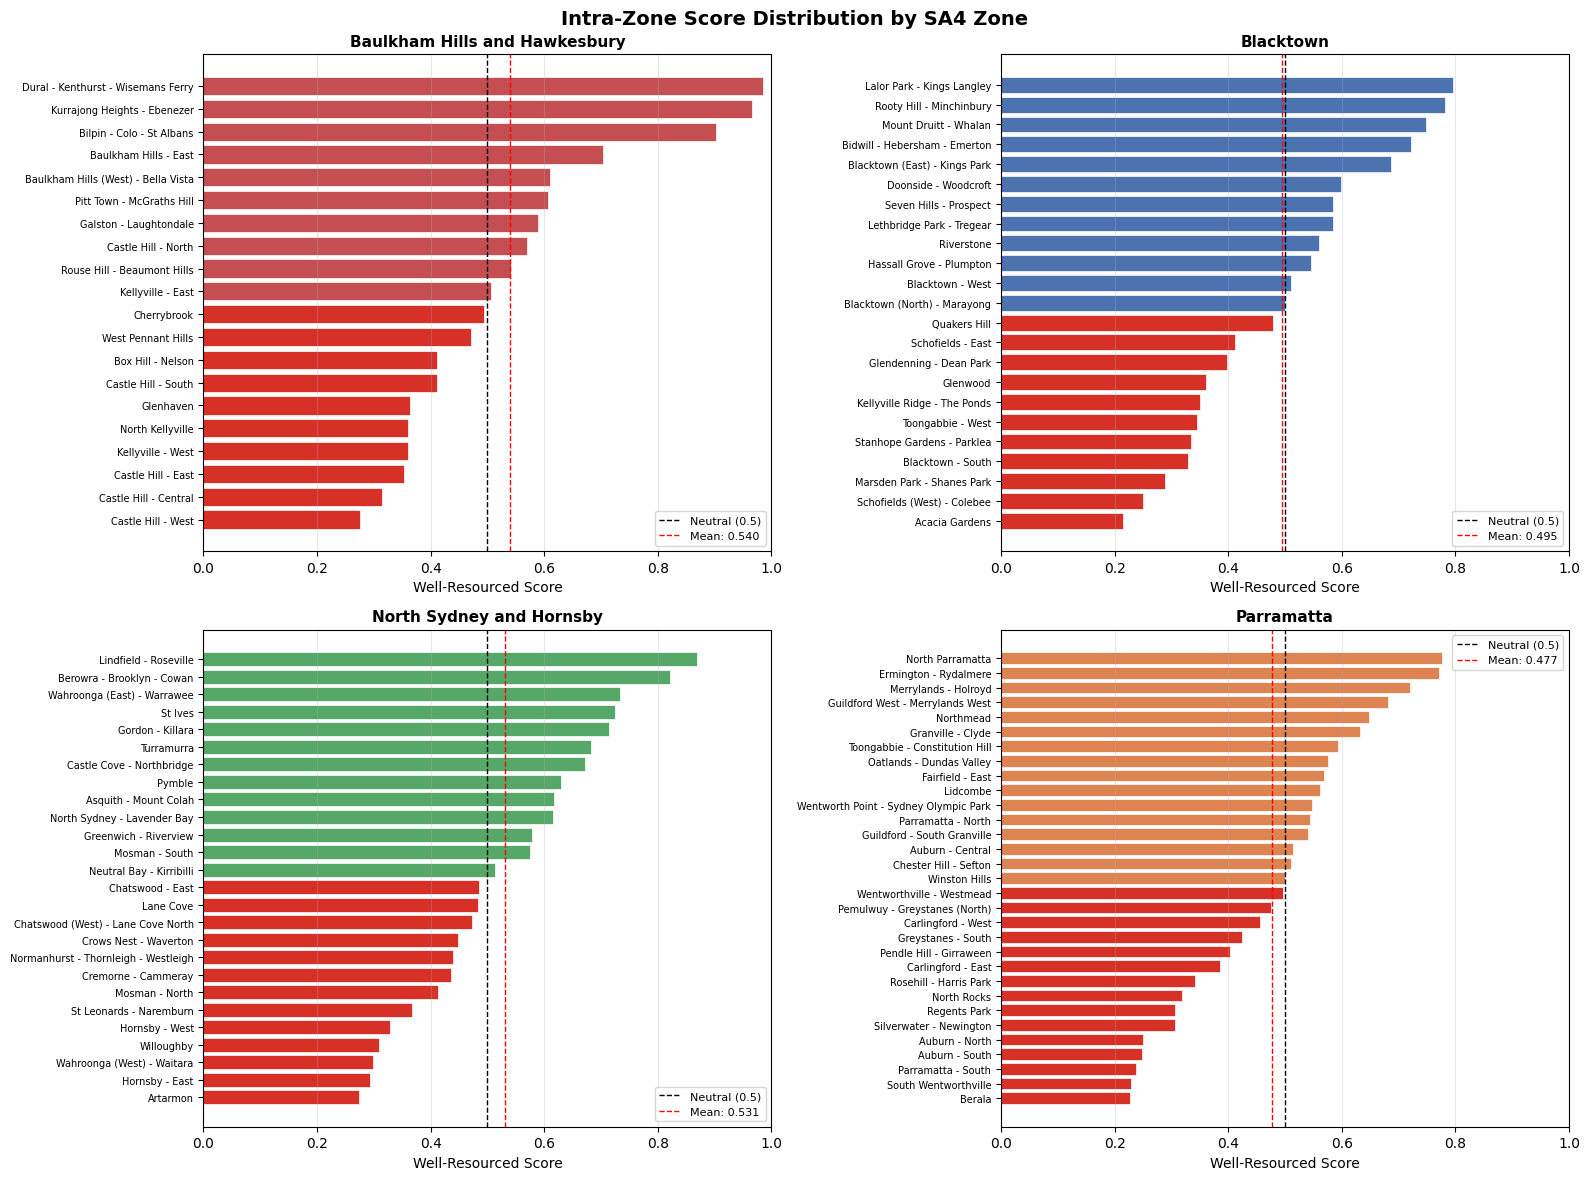

✓ Intra-zone distribution saved.


In [19]:
zones = all_scores_df["sa4_name"].unique()
zone_colours = {
    "Sydney - Blacktown":                      "#4C72B0",
    "Sydney - Parramatta":                     "#DD8452",
    "Sydney - North Sydney and Hornsby":       "#55A868",
    "Sydney - Baulkham Hills and Hawkesbury":  "#C44E52",
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Intra-Zone Score Distribution by SA4 Zone",
             fontsize=14, fontweight="bold")

for ax, zone in zip(axes.flatten(), zones):
    zone_df = all_scores_df[all_scores_df["sa4_name"] == zone].sort_values("score_final")
    colour = zone_colours.get(zone, "#4C72B0")

    colours = ["#d73027" if s < 0.5 else colour for s in zone_df["score_final"]]
    ax.barh(zone_df["sa2_name"], zone_df["score_final"],
            color=colours, edgecolor="white", linewidth=0.5)
    ax.axvline(0.5, color="black", linestyle="--", linewidth=1, label="Neutral (0.5)")
    ax.axvline(zone_df["score_final"].mean(), color="red", linestyle="--",
               linewidth=1, label=f'Mean: {zone_df["score_final"].mean():.3f}')
    ax.set_title(zone.replace("Sydney - ", ""), fontsize=11, fontweight="bold")
    ax.set_xlabel("Well-Resourced Score")
    ax.tick_params(axis="y", labelsize=7)
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("task4_intra_zone_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Intra-zone distribution saved.")

## 4.3 Inter-Zone Score Comparison

We compare scores across all four SA4 zones to identify whether location 
within Greater Sydney influences how well-resourced an area is.

Inter-Zone Summary Statistics:
                                        avg_score  median_score  std_score  min_score  max_score  range_score  sa2_count  avg_poi
sa4_name                                                                                                                         
Sydney - Baulkham Hills and Hawkesbury     0.5396           0.5     0.2109     0.2747     0.9859       0.7111         20  87.5000
Sydney - Blacktown                         0.4948           0.5     0.1747     0.2142     0.7953       0.5811         23  59.4783
Sydney - North Sydney and Hornsby          0.5307           0.5     0.1699     0.2733     0.8685       0.5953         26  91.1154
Sydney - Parramatta                        0.4771           0.5     0.1623     0.2268     0.7757       0.5489         31  66.5484


/var/folders/qn/x0st3myn2xj8402zn_fmv1h00000gn/T/ipykernel_42762/2750286150.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(zone_labels, rotation=20, ha="right", fontsize=9)


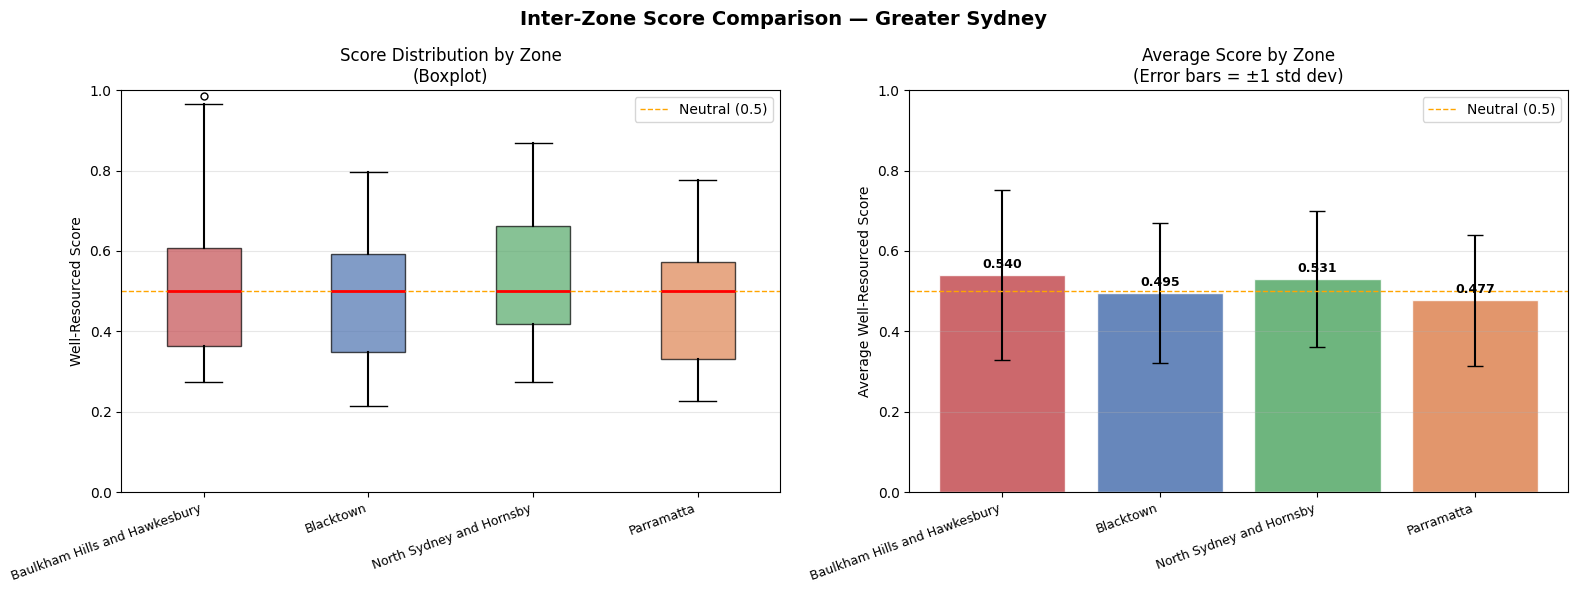

✓ Inter-zone comparison saved.


In [20]:
zone_summary = all_scores_df.groupby("sa4_name").agg(
    avg_score=("score_final", "mean"),
    median_score=("score_final", "median"),
    std_score=("score_final", "std"),
    min_score=("score_final", "min"),
    max_score=("score_final", "max"),
    range_score=("score_final", lambda x: x.max() - x.min()),
    sa2_count=("sa2_name", "count"),
    avg_poi=("poi_count", "mean"),
).round(4)

print("Inter-Zone Summary Statistics:")
print(zone_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Inter-Zone Score Comparison — Greater Sydney",
             fontsize=14, fontweight="bold")

# --- Plot 1: Grouped boxplot ---
ax1 = axes[0]
data_by_zone = [
    all_scores_df[all_scores_df["sa4_name"] == zone]["score_final"].values
    for zone in zones
]
bp = ax1.boxplot(
    data_by_zone,
    patch_artist=True,
    medianprops=dict(color="red", linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    flierprops=dict(marker="o", markersize=5)
)
for patch, zone in zip(bp["boxes"], zones):
    patch.set_facecolor(zone_colours.get(zone, "#4C72B0"))
    patch.set_alpha(0.7)

ax1.set_xticklabels(
    [z.replace("Sydney - ", "") for z in zones],
    rotation=20, ha="right", fontsize=9
)
ax1.axhline(0.5, color="orange", linestyle="--", linewidth=1, label="Neutral (0.5)")
ax1.set_title("Score Distribution by Zone\n(Boxplot)")
ax1.set_ylabel("Well-Resourced Score")
ax1.set_ylim(0, 1)
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

# --- Plot 2: Average score bar chart with std error bars ---
ax2 = axes[1]
zone_labels = [z.replace("Sydney - ", "") for z in zone_summary.index]
bars = ax2.bar(
    zone_labels,
    zone_summary["avg_score"],
    color=[zone_colours.get(z, "#4C72B0") for z in zone_summary.index],
    edgecolor="white",
    alpha=0.85
)
ax2.errorbar(
    zone_labels,
    zone_summary["avg_score"],
    yerr=zone_summary["std_score"],
    fmt="none",
    color="black",
    capsize=6,
    linewidth=1.5
)
ax2.axhline(0.5, color="orange", linestyle="--", linewidth=1, label="Neutral (0.5)")
for bar, val in zip(bars, zone_summary["avg_score"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax2.set_title("Average Score by Zone\n(Error bars = ±1 std dev)")
ax2.set_ylabel("Average Well-Resourced Score")
ax2.set_xticklabels(zone_labels, rotation=20, ha="right", fontsize=9)
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("task4_inter_zone_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Inter-zone comparison saved.")